# 09 固定窗口每日重估与次日方差预测面板

**统计项目：** 论文 Table 7 之前的完整滚动预测生成步骤。

## 1. 在做什么，以及经济意义

本项把前面已经估计过的模型真正放到时间轴上：在每个样本外交易日到来前，只用固定长度滚动窗重新估计参数，再预测下一交易日的方差。经济上，它检验长记忆、条件异方差和更高采样频率是否能转化为可实时获得的风险预测，而不再停留于入样本参数解释。

输出是项目专属、带指纹和验收记录的逐日预测成果；真实波动代理、损失和模型优胜判断留到第 10 项，避免目标变量进入拟合。

## 2. 论文公式、Table 7 与当前复现等级

论文公式 (11)–(13) 先以全文样本槽位尺度 `S_n` 去季节化盘中收益，再把多步方差逐槽乘回 `S_n^2`。论文交易日有 240 分钟，因此预测 16/8/4 步；当前湖仓真实日盘为 225 分钟，本项目依冻结口径预测 15/8/4 步，30/60 分钟末槽分别只有 15/45 分钟。

每个预测日的论文主面板严格为 15 个模型：盘中 GARCH/FIGARCH/IGARCH × 15/30/60 分钟共 9 个、日频三家族共 3 个、ARFIMA × 三频率共 3 个。日频模型一步预测；ARFIMA 预测 `0.5*log(RV)` 后用 `exp(2*y_hat)` 还原，不做未披露偏差修正。

论文未披露窗口长度、每日重估细节、warm start、失败规则、FIGARCH 多步算法和均值平方项。项目冻结为：窗口日数等于初始样本、每日完整重估、只预测条件创新方差、不加均值预测平方；FIGARCH 使用 `arch 8.0.0` analytic forecast 与 1000 阶截断。全文季节因子是唯一明示的论文前视基线；另以每个 forecast origin 截至当日的全部历史槽位平方收益估计一组因子，把该因子快照用于整个固定窗并另外重估 9 个盘中模型，作为无前视敏感性。

In [1]:
from __future__ import annotations

from datetime import date, datetime, timezone
import gc
import hashlib
import json
import os
import pathlib
import re
import sys
import time

project_markers = [".git", ".env", "config/settings.py"]
current_path = pathlib.Path.cwd().resolve()

for candidate_root in [current_path, *current_path.parents]:
    if all((candidate_root / marker).exists() for marker in project_markers):
        sys.path.insert(0, str(candidate_root))
        sys.path.insert(0, str(candidate_root / "02_Futures_Lakehouse"))
        project_root = candidate_root
        break
else:
    raise RuntimeError("未找到项目根目录")

expected_python = pathlib.Path("E:/anaconda3/envs/latitude/python.exe").resolve()
current_python = pathlib.Path(sys.executable).resolve()
assert current_python == expected_python, (
    f"必须使用 latitude 环境解释器 {expected_python}，实际为 {current_python}"
)

import arch
from arch.univariate import FIGARCH, GARCH, StudentsT
from joblib import Parallel, delayed, parallel_config
import joblib
import matplotlib.pyplot as plt
import nbformat
import numpy as np
import pandas as pd
import pyarrow as pa
import pyarrow.dataset as ds
import pyarrow.parquet as pq
import scipy
from scipy.optimize import Bounds, LinearConstraint, minimize
from scipy.signal import fftconvolve, lfilter
import statsmodels
from IPython.display import Markdown, display

from config.data_contracts import (
    FUTURES_BAR_CALENDAR_SCHEMA,
    FUTURES_CONTRACT_CALENDAR_SCHEMA,
    FUTURES_MINUTE_SCHEMA,
    FUTURES_VARIETY_CALENDAR_SCHEMA,
    arrow_to_pandas,
    validate_arrow_table,
)
from notebook_schema_browser import display_schema_metadata
from config.settings import settings

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 400)
pd.set_option("display.width", 240)

print(f"Python: {sys.executable}")
print(
    f"arch={arch.__version__}; SciPy={scipy.__version__}; "
    f"statsmodels={statsmodels.__version__}; joblib={joblib.__version__}"
)
print(f"项目根目录: {project_root}")
print(f"正式湖仓根目录: {settings.futures_lake_root}")

Python: E:\anaconda3\envs\latitude\python.exe
arch=8.0.0; SciPy=1.17.1; statsmodels=0.14.6; joblib=1.5.3
项目根目录: E:\Latitude_Analytics_v2
正式湖仓根目录: E:\Latitude_Analytics_v2\03_Futures_Database\futures_lake


## 3. 开篇 Schema metadata 浏览器

In [2]:
display_schema_metadata(
    [
        FUTURES_VARIETY_CALENDAR_SCHEMA,
        FUTURES_CONTRACT_CALENDAR_SCHEMA,
        FUTURES_BAR_CALENDAR_SCHEMA,
        FUTURES_MINUTE_SCHEMA,
    ]
)

英文表名,中文表名,字段数,主键,Hive 分区,Schema 版本
dim_futures_variety_calendar,期货品种交易日历维度表,8,"exchange_code,underlying_code,trading_date","exchange_code,year,month",1.2.0
dim_futures_contract_calendar,期货合约 Session 日历维度表,21,"contract_code,trading_date,session_number","exchange_code,year,month",1.2.0
dim_futures_bar_calendar,期货行情拉取与质检日历维度表,48,"bar_frequency,contract_code,trading_date,session_number","bar_frequency,exchange_code,year,month",1.4.0
fact_futures_minute,国内期货合约一分钟行情事实表,17,"contract_code,bar_at","exchange_code,underlying_code,year,month",1.5.0


## 4. 参数、固定样本与代码步骤

代码依次完成：固定合约链与分钟收益 → 日收益/RV/季节因子 → 120 个独立滚动模型流 → 31,200 次每日重估 → 盘中多步重新季节化 → 完整面板与独立门禁。

默认 `read_validated` 只读完全验收的确定性 run；只有外层在已获授权长批次中显式设置 `compute_or_resume`，才会创建或续算项目成果。不存在成果时绝不从只读模式静默切换为昂贵计算。

为使长批次可重复且可完成，每个模型流首个、每 50 个及最后一个 origin 使用固定起点网格；其他日期同时优化前日最优参数和当前窗口的固定安全起点，择最低成功可行 NLL。warm start 只提供起点；每个窗口都重新计算 OLS 均值起点、backcast、variance bounds、约束、Student-t bounds 和完整似然。

In [3]:
exchange_code = "XSGE"
sample_start = date(2010, 1, 4)
sample_end = date(2026, 8, 28)
zero_return_tolerance = 1e-12
rv_floor_multiplier = 0.5
daily_return_model_scale = 100.0

figarch_truncation = 1000
garch_persistence_cap = 0.999999
arma_absolute_bound = 0.999
fractional_d_bound = 0.499
optimizer_max_iterations = 1000
garch_optimizer_ftol = 1e-8
arfima_optimizer_ftol = 1e-10
optimization_feasibility_tolerance = 1e-7
parameter_boundary_tolerance = 1e-4
deterministic_theta_starts = (-0.25, 0.0, 0.25)
arfima_phi_starts = (-0.5, 0.0, 0.5)
arfima_d_starts = (-0.2, 0.2, 0.4)
rolling_anchor_interval = 50

# 项目内成果默认只读；只有明确获批的长批次才由外层设置 compute_or_resume。
artifact_mode = os.environ.get(
    "ITEM09_ARTIFACT_MODE",
    "read_validated",
).strip()
assert artifact_mode in {"read_validated", "compute_or_resume"}
artifact_contract_version = "item09-rolling-forecast-stream-v1"
artifact_compression = "zstd"
project_dir = (
    project_root
    / "01_project_collection"
    / "china_commodity_futures_intraday_volatility_forecasting_reproduction"
)
artifact_root = project_dir / "data" / "item09"
artifact_storage_layout = "flat-v2"

# 失败现场表明 3 个长寿 worker 下存在内存压力风险；默认降到 2。
# 每个模型流内部仍严格按日期顺序 warm start，跨流才并行。
parallel_jobs = int(os.environ.get("ITEM09_PARALLEL_JOBS", "2"))
assert 1 <= parallel_jobs <= 3

sample_spec_df = pd.DataFrame(
    [
        ("AL", "AL", date(2010, 1, 4), date(2026, 8, 28), 300, "论文品种"),
        ("CU", "CU", date(2010, 1, 4), date(2026, 8, 28), 300, "论文品种"),
        ("FU_legacy", "FU", date(2010, 1, 4), date(2011, 9, 30), 200, "论文品种：旧产品段"),
        ("FU_relaunched", "FU", date(2020, 1, 2), date(2026, 8, 28), 200, "论文品种：稳定重启段"),
        ("RB", "RB", date(2010, 1, 4), date(2026, 8, 28), 300, "论文外扩展品种"),
    ],
    columns=[
        "series_id",
        "underlying_code",
        "sample_start",
        "sample_end",
        "oos_days",
        "research_role",
    ],
)
sample_spec_df["sample_start"] = pd.to_datetime(sample_spec_df["sample_start"])
sample_spec_df["sample_end"] = pd.to_datetime(sample_spec_df["sample_end"])
series_order = sample_spec_df["series_id"].tolist()

interval_spec_df = pd.DataFrame(
    [
        ("15-min", 15, 15, 15),
        ("30-min", 30, 8, 15),
        ("60-min", 60, 4, 45),
    ],
    columns=[
        "interval_label",
        "target_interval_minutes",
        "expected_daily_slots",
        "expected_last_slot_minutes",
    ],
)
interval_order = interval_spec_df["interval_label"].tolist()
intraday_interval_order = interval_order.copy()
model_family_order = ["GARCH", "FIGARCH", "IGARCH"]
seasonality_variant_order = ["paper_full_sample", "expanding_no_lookahead"]

display(sample_spec_df)
display(interval_spec_df)
display(
    pd.DataFrame(
        [
            ("primary", 15, "盘中 9 + 日频 3 + ARFIMA 3"),
            ("seasonality_sensitivity", 9, "盘中 9 个模型在每个 origin 重新估计可见历史因子并重估模型"),
        ],
        columns=["panel_role", "models_per_forecast_date", "model_set"],
    )
)
print(f"成果模式: {artifact_mode}")
print(f"项目专属成果根目录: {artifact_root}")
print(f"并行模型流 worker 数: {parallel_jobs}")

,series_id,underlying_code,sample_start,sample_end,oos_days,research_role
0,AL,AL,2010-01-04,2026-08-28,300,论文品种
1,CU,CU,2010-01-04,2026-08-28,300,论文品种
2,FU_legacy,FU,2010-01-04,2011-09-30,200,论文品种：旧产品段
3,FU_relaunched,FU,2020-01-02,2026-08-28,200,论文品种：稳定重启段
4,RB,RB,2010-01-04,2026-08-28,300,论文外扩展品种


,interval_label,target_interval_minutes,expected_daily_slots,expected_last_slot_minutes
0,15-min,15,15,15
1,30-min,30,8,15
2,60-min,60,4,45


,panel_role,models_per_forecast_date,model_set
0,primary,15,盘中 9 + 日频 3 + ARFIMA 3
1,seasonality_sensitivity,9,盘中 9 个模型在每个 origin 重新估计可见历史因子并重估模型


成果模式: read_validated
项目专属成果根目录: E:\Latitude_Analytics_v2\01_project_collection\china_commodity_futures_intraday_volatility_forecasting_reproduction\data\item09
并行模型流 worker 数: 1


## 5. 直接 PyArrow 过滤读取与固定三个月合约链

In [4]:
source_schema_by_role = {
    "variety_calendar": FUTURES_VARIETY_CALENDAR_SCHEMA,
    "contract_calendar": FUTURES_CONTRACT_CALENDAR_SCHEMA,
    "bar_calendar": FUTURES_BAR_CALENDAR_SCHEMA,
    "minute_fact": FUTURES_MINUTE_SCHEMA,
}
source_dataset_by_role = {}
source_contract_audit_rows = []

for source_role, source_schema in source_schema_by_role.items():
    source_metadata = {
        key.decode("utf-8"): value.decode("utf-8")
        for key, value in source_schema.metadata.items()
    }
    table_name = source_metadata["table_name"]
    primary_key = source_metadata["primary_key"].split(",")
    partition_columns = source_metadata["partition_columns"].split(",")
    table_path = settings.futures_lake_root / "silver" / table_name
    partitioning = ds.partitioning(
        pa.schema(
            [source_schema.field(column_name) for column_name in partition_columns]
        ),
        flavor="hive",
    )
    source_dataset = ds.dataset(
        table_path,
        format="parquet",
        partitioning=partitioning,
    )

    physical_mismatches = []
    for expected_field in source_schema:
        actual_field = source_dataset.schema.field(expected_field.name)
        if (
            actual_field.type != expected_field.type
            or actual_field.nullable != expected_field.nullable
        ):
            physical_mismatches.append(
                {
                    "field": expected_field.name,
                    "expected_type": str(expected_field.type),
                    "actual_type": str(actual_field.type),
                    "expected_nullable": expected_field.nullable,
                    "actual_nullable": actual_field.nullable,
                }
            )
    if physical_mismatches:
        raise TypeError({table_name: physical_mismatches})

    source_dataset_by_role[source_role] = source_dataset
    source_contract_audit_rows.append(
        {
            "source_role": source_role,
            "table_name": table_name,
            "primary_key": ",".join(primary_key),
            "partition_columns": ",".join(partition_columns),
            "physical_mismatch_count": len(physical_mismatches),
        }
    )

source_contract_audit_df = pd.DataFrame(source_contract_audit_rows)
display(source_contract_audit_df)

,source_role,table_name,primary_key,partition_columns,physical_mismatch_count
0,variety_calendar,dim_futures_variety_calendar,"exchange_code,underlying_code,trading_date","exchange_code,year,month",0
1,contract_calendar,dim_futures_contract_calendar,"contract_code,trading_date,session_number","exchange_code,year,month",0
2,bar_calendar,dim_futures_bar_calendar,"bar_frequency,contract_code,trading_date,session_number","bar_frequency,exchange_code,year,month",0
3,minute_fact,fact_futures_minute,"contract_code,bar_at","exchange_code,underlying_code,year,month",0


In [5]:
trading_date_field = ds.field("trading_date")
underlying_field = ds.field("underlying_code")
base_filter = (
    (ds.field("exchange_code") == exchange_code)
    & (ds.field("year") >= sample_start.year)
    & (ds.field("year") <= sample_end.year)
)
main_series_filter = (
    underlying_field.isin(["AL", "CU", "RB"])
    & (trading_date_field >= pa.scalar(sample_start, type=pa.date32()))
    & (trading_date_field <= pa.scalar(sample_end, type=pa.date32()))
)
fu_series_filter = (
    (underlying_field == "FU")
    & (
        (
            (trading_date_field >= pa.scalar(date(2010, 1, 4), type=pa.date32()))
            & (trading_date_field <= pa.scalar(date(2011, 9, 30), type=pa.date32()))
        )
        | (
            (trading_date_field >= pa.scalar(date(2020, 1, 2), type=pa.date32()))
            & (trading_date_field <= pa.scalar(date(2026, 8, 28), type=pa.date32()))
        )
    )
)
research_sample_filter = base_filter & (main_series_filter | fu_series_filter)

variety_columns = [
    "underlying_code",
    "exchange_code",
    "trading_date",
    "active_contract_count",
]
variety_projection_schema = pa.schema(
    [
        FUTURES_VARIETY_CALENDAR_SCHEMA.field(column_name)
        for column_name in variety_columns
    ]
)
variety_calendar_table = source_dataset_by_role["variety_calendar"].to_table(
    columns=variety_columns,
    filter=research_sample_filter,
)
validated_variety_calendar_table = validate_arrow_table(
    variety_calendar_table,
    variety_projection_schema,
)
variety_calendar_df = arrow_to_pandas(
    validated_variety_calendar_table,
    variety_projection_schema,
)
variety_calendar_df["trading_date"] = pd.to_datetime(
    variety_calendar_df["trading_date"]
)

expected_sample_pieces = []
for sample_spec in sample_spec_df.itertuples(index=False):
    expected_series_df = variety_calendar_df.loc[
        (variety_calendar_df["underlying_code"] == sample_spec.underlying_code)
        & (variety_calendar_df["trading_date"] >= sample_spec.sample_start)
        & (variety_calendar_df["trading_date"] <= sample_spec.sample_end)
    ].copy()
    expected_series_df.insert(0, "series_id", sample_spec.series_id)
    expected_sample_pieces.append(expected_series_df)

expected_sample_df = pd.concat(
    expected_sample_pieces,
    ignore_index=True,
).sort_values(["series_id", "trading_date"], ignore_index=True)

target_delivery_period = (
    pd.PeriodIndex(expected_sample_df["trading_date"], freq="M") + 3
)
expected_sample_df["target_delivery_year"] = target_delivery_period.year
expected_sample_df["target_delivery_month"] = target_delivery_period.month
expected_sample_df["expected_contract_code"] = (
    expected_sample_df["underlying_code"].astype("string")
    + expected_sample_df["target_delivery_year"].mod(100).astype("string").str.zfill(2)
    + expected_sample_df["target_delivery_month"].astype("string").str.zfill(2)
    + "."
    + expected_sample_df["exchange_code"].astype("string")
)

display(
    expected_sample_df.groupby("series_id", observed=True)["trading_date"]
    .agg(
        expected_trading_days="size",
        first_date="min",
        last_date="max",
    )
    .reset_index()
)

,series_id,expected_trading_days,first_date,last_date
0,AL,4045,2010-01-04,2026-08-28
1,CU,4045,2010-01-04,2026-08-28
2,FU_legacy,426,2010-01-04,2011-09-30
3,FU_relaunched,1614,2020-01-02,2026-08-28
4,RB,4045,2010-01-04,2026-08-28


In [6]:
contract_columns = [
    "contract_code",
    "exchange_code",
    "underlying_code",
    "trading_date",
    "session_number",
    "session_start_at",
    "session_end_at",
    "is_night_session",
    "minute_count",
]
contract_projection_schema = pa.schema(
    [
        FUTURES_CONTRACT_CALENDAR_SCHEMA.field(column_name)
        for column_name in contract_columns
    ]
)
day_contract_filter = research_sample_filter & (
    ds.field("is_night_session") == False
)
contract_calendar_table = source_dataset_by_role["contract_calendar"].to_table(
    columns=contract_columns,
    filter=day_contract_filter,
)
validated_contract_calendar_table = validate_arrow_table(
    contract_calendar_table,
    contract_projection_schema,
)
contract_calendar_df = arrow_to_pandas(
    validated_contract_calendar_table,
    contract_projection_schema,
)
contract_calendar_df["trading_date"] = pd.to_datetime(
    contract_calendar_df["trading_date"]
)

contract_code_parts = contract_calendar_df["contract_code"].astype("string").str.extract(
    r"^([A-Z]+)(\d{4})\.([A-Z]+)$"
)
if not contract_code_parts.notna().all().all():
    invalid_contract_codes = contract_calendar_df.loc[
        contract_code_parts.isna().any(axis=1),
        "contract_code",
    ].drop_duplicates()
    raise ValueError(
        f"发现无法解析的固定月份合约代码: {invalid_contract_codes.tolist()}"
    )

contract_calendar_df["code_underlying"] = contract_code_parts[0]
contract_calendar_df["delivery_year"] = (
    2000 + contract_code_parts[1].str[:2].astype("int16")
)
contract_calendar_df["delivery_month"] = (
    contract_code_parts[1].str[2:].astype("int8")
)
contract_calendar_df["code_exchange"] = contract_code_parts[2]
trade_plus_three_period = (
    pd.PeriodIndex(contract_calendar_df["trading_date"], freq="M") + 3
)
contract_calendar_df["is_target_delivery"] = (
    contract_calendar_df["delivery_year"].eq(trade_plus_three_period.year)
    & contract_calendar_df["delivery_month"].eq(trade_plus_three_period.month)
)

assert (
    contract_calendar_df["code_underlying"]
    == contract_calendar_df["underlying_code"]
).all()
assert (
    contract_calendar_df["code_exchange"]
    == contract_calendar_df["exchange_code"]
).all()
assert not contract_calendar_df["is_night_session"].any()

target_session_df = contract_calendar_df.loc[
    contract_calendar_df["is_target_delivery"]
].copy()
target_contract_count_df = (
    target_session_df.groupby(
        ["underlying_code", "trading_date"],
        observed=True,
    )["contract_code"]
    .nunique()
    .rename("target_contract_count")
    .reset_index()
)
target_contract_day_df = (
    target_session_df.groupby(
        [
            "underlying_code",
            "trading_date",
            "contract_code",
            "delivery_year",
            "delivery_month",
        ],
        observed=True,
        sort=True,
    )
    .agg(
        day_session_count=("session_number", "nunique"),
        day_minute_count=("minute_count", "sum"),
    )
    .reset_index()
)

contract_mapping_audit_df = expected_sample_df.merge(
    target_contract_count_df,
    on=["underlying_code", "trading_date"],
    how="left",
    validate="one_to_one",
)
contract_mapping_audit_df["target_contract_count"] = (
    contract_mapping_audit_df["target_contract_count"]
    .fillna(0)
    .astype("int64")
)
assert contract_mapping_audit_df["target_contract_count"].le(1).all()

contract_mapping_audit_df = contract_mapping_audit_df.merge(
    target_contract_day_df,
    on=["underlying_code", "trading_date"],
    how="left",
    validate="one_to_one",
)
contract_mapping_audit_df["mapping_status"] = np.where(
    contract_mapping_audit_df["contract_code"].notna(),
    "selected",
    "excluded_target_contract_not_listed",
)
missing_contract_mapping_df = contract_mapping_audit_df.loc[
    contract_mapping_audit_df["mapping_status"] != "selected",
    [
        "series_id",
        "trading_date",
        "expected_contract_code",
        "target_contract_count",
        "mapping_status",
    ],
].copy()

known_missing_keys_df = expected_sample_df.loc[
    (expected_sample_df["series_id"] == "FU_legacy")
    & (
        expected_sample_df["trading_date"].dt.to_period("M")
        == pd.Period("2010-11")
    ),
    ["series_id", "trading_date", "expected_contract_code"],
].sort_values(["series_id", "trading_date"], ignore_index=True)
actual_missing_keys_df = missing_contract_mapping_df[
    ["series_id", "trading_date", "expected_contract_code"]
].sort_values(["series_id", "trading_date"], ignore_index=True)
assert actual_missing_keys_df.equals(known_missing_keys_df)
assert set(actual_missing_keys_df["expected_contract_code"]) == {
    "FU1102.XSGE"
}

contract_series_df = contract_mapping_audit_df.loc[
    contract_mapping_audit_df["mapping_status"] == "selected"
].copy()
contract_series_df = contract_series_df.sort_values(
    ["series_id", "trading_date"],
    ignore_index=True,
)
contract_series_df["previous_contract_code"] = (
    contract_series_df.groupby(
        "series_id",
        observed=True,
    )["contract_code"].shift()
)
contract_series_df["is_roll_day"] = (
    contract_series_df["previous_contract_code"].notna()
    & contract_series_df["contract_code"].ne(
        contract_series_df["previous_contract_code"]
    )
).astype("bool")

selected_target_session_df = target_session_df.merge(
    contract_series_df[
        [
            "series_id",
            "underlying_code",
            "trading_date",
            "contract_code",
            "delivery_year",
            "delivery_month",
            "is_roll_day",
        ]
    ],
    on=[
        "underlying_code",
        "trading_date",
        "contract_code",
        "delivery_year",
        "delivery_month",
    ],
    how="inner",
    validate="many_to_one",
)
assert selected_target_session_df.groupby(
    ["series_id", "trading_date"],
    observed=True,
)["session_number"].nunique().eq(3).all()

display(missing_contract_mapping_df)
display(
    contract_series_df.groupby("series_id", observed=True)
    .agg(
        selected_trading_days=("trading_date", "size"),
        first_selected_date=("trading_date", "min"),
        last_selected_date=("trading_date", "max"),
        unique_contracts=("contract_code", "nunique"),
        roll_days=("is_roll_day", "sum"),
    )
    .reset_index()
)

,series_id,trading_date,expected_contract_code,target_contract_count,mapping_status
8287,FU_legacy,2010-11-01,FU1102.XSGE,0,excluded_target_contract_not_listed
8288,FU_legacy,2010-11-02,FU1102.XSGE,0,excluded_target_contract_not_listed
8289,FU_legacy,2010-11-03,FU1102.XSGE,0,excluded_target_contract_not_listed
8290,FU_legacy,2010-11-04,FU1102.XSGE,0,excluded_target_contract_not_listed
8291,FU_legacy,2010-11-05,FU1102.XSGE,0,excluded_target_contract_not_listed
8292,FU_legacy,2010-11-08,FU1102.XSGE,0,excluded_target_contract_not_listed
8293,FU_legacy,2010-11-09,FU1102.XSGE,0,excluded_target_contract_not_listed
8294,FU_legacy,2010-11-10,FU1102.XSGE,0,excluded_target_contract_not_listed
8295,FU_legacy,2010-11-11,FU1102.XSGE,0,excluded_target_contract_not_listed
8296,FU_legacy,2010-11-12,FU1102.XSGE,0,excluded_target_contract_not_listed


,series_id,selected_trading_days,first_selected_date,last_selected_date,unique_contracts,roll_days
0,AL,4045,2010-01-04,2026-08-28,200,199
1,CU,4045,2010-01-04,2026-08-28,200,199
2,FU_legacy,404,2010-01-04,2011-09-30,20,19
3,FU_relaunched,1614,2020-01-02,2026-08-28,80,79
4,RB,4045,2010-01-04,2026-08-28,200,199


In [7]:
bar_columns = [
    "bar_frequency",
    "contract_code",
    "exchange_code",
    "underlying_code",
    "trading_date",
    "session_number",
    "is_night_session",
    "is_fetch_required",
    "expected_bar_count",
    "is_fetch_completed",
    "actual_bar_count",
    "missing_bar_count",
]
bar_projection_schema = pa.schema(
    [FUTURES_BAR_CALENDAR_SCHEMA.field(column_name) for column_name in bar_columns]
)
day_bar_filter = (
    research_sample_filter
    & (ds.field("bar_frequency") == "1m")
    & (ds.field("is_night_session") == False)
)
bar_calendar_table = source_dataset_by_role["bar_calendar"].to_table(
    columns=bar_columns,
    filter=day_bar_filter,
)
validated_bar_calendar_table = validate_arrow_table(
    bar_calendar_table,
    bar_projection_schema,
)
bar_calendar_df = arrow_to_pandas(
    validated_bar_calendar_table,
    bar_projection_schema,
)
bar_calendar_df["trading_date"] = pd.to_datetime(
    bar_calendar_df["trading_date"]
)

bar_join_key = [
    "contract_code",
    "exchange_code",
    "underlying_code",
    "trading_date",
    "session_number",
]
selected_bar_session_df = selected_target_session_df[
    [
        "series_id",
        "contract_code",
        "exchange_code",
        "underlying_code",
        "trading_date",
        "session_number",
        "delivery_year",
        "delivery_month",
        "is_roll_day",
        "minute_count",
    ]
].merge(
    bar_calendar_df,
    on=bar_join_key,
    how="left",
    validate="one_to_one",
    indicator=True,
)
selected_bar_session_df["eligible_session"] = (
    selected_bar_session_df["_merge"].eq("both")
    & selected_bar_session_df["is_fetch_required"].eq(True)
    & selected_bar_session_df["is_fetch_completed"].eq(True)
    & selected_bar_session_df["expected_bar_count"].eq(
        selected_bar_session_df["actual_bar_count"]
    )
    & selected_bar_session_df["missing_bar_count"].eq(0)
)

selected_day_key = [
    "series_id",
    "contract_code",
    "exchange_code",
    "underlying_code",
    "trading_date",
    "delivery_year",
    "delivery_month",
    "is_roll_day",
]
complete_contract_day_df = (
    selected_bar_session_df.groupby(
        selected_day_key,
        observed=True,
        sort=True,
    )
    .agg(
        day_session_count=("session_number", "nunique"),
        upstream_session_rows=("bar_frequency", "count"),
        eligible_session_count=("eligible_session", "sum"),
        expected_minute_rows=("expected_bar_count", "sum"),
        actual_minute_rows=("actual_bar_count", "sum"),
        missing_minute_rows=("missing_bar_count", "sum"),
    )
    .reset_index()
)
complete_contract_day_df["is_complete_contract_day"] = (
    complete_contract_day_df["day_session_count"].eq(3)
    & complete_contract_day_df["upstream_session_rows"].eq(3)
    & complete_contract_day_df["eligible_session_count"].eq(3)
    & complete_contract_day_df["expected_minute_rows"].eq(225)
    & complete_contract_day_df["actual_minute_rows"].eq(225)
    & complete_contract_day_df["missing_minute_rows"].eq(0)
)

complete_day_keys_df = complete_contract_day_df.loc[
    complete_contract_day_df["is_complete_contract_day"],
    selected_day_key,
].copy()
complete_session_keys_df = selected_bar_session_df.merge(
    complete_day_keys_df,
    on=selected_day_key,
    how="inner",
    validate="many_to_one",
)
complete_session_keys_df = complete_session_keys_df.loc[
    complete_session_keys_df["eligible_session"]
].copy()
complete_session_keys_df["calendar_year"] = (
    complete_session_keys_df["trading_date"].dt.year.astype("int16")
)

coverage_df = (
    contract_series_df.groupby("series_id", observed=True)
    .agg(selected_contract_days=("trading_date", "size"))
    .reset_index()
    .merge(
        complete_contract_day_df.groupby("series_id", observed=True)
        ["is_complete_contract_day"]
        .sum()
        .rename("complete_contract_days")
        .reset_index(),
        on="series_id",
        validate="one_to_one",
    )
)
coverage_df["complete_pct"] = (
    100
    * coverage_df["complete_contract_days"]
    / coverage_df["selected_contract_days"]
)
display(coverage_df.round(4))

,series_id,selected_contract_days,complete_contract_days,complete_pct
0,AL,4045,4045,100.0
1,CU,4045,4045,100.0
2,FU_legacy,404,404,100.0
3,FU_relaunched,1614,1614,100.0
4,RB,4045,4045,100.0


## 6. 一次分钟扫描生成 15/30/60 分钟收益

In [8]:
minute_columns = [
    "contract_code",
    "exchange_code",
    "underlying_code",
    "trading_date",
    "session_number",
    "bar_at",
    "open",
    "close",
]
minute_projection_schema = pa.schema(
    [FUTURES_MINUTE_SCHEMA.field(column_name) for column_name in minute_columns]
)
minute_session_join_key = [
    "contract_code",
    "exchange_code",
    "underlying_code",
    "trading_date",
    "session_number",
]
minute_session_context_columns = [
    "series_id",
    "contract_code",
    "exchange_code",
    "underlying_code",
    "trading_date",
    "session_number",
    "delivery_year",
    "delivery_month",
    "is_roll_day",
    "expected_bar_count",
]
multiscale_return_pieces = []
minute_read_audit_rows = []
slot_audit_rows = []

for (
    series_id,
    calendar_year,
), partition_session_keys_df in complete_session_keys_df.groupby(
    ["series_id", "calendar_year"],
    observed=True,
    sort=True,
):
    partition_started_at = time.perf_counter()
    partition_session_keys_df = partition_session_keys_df[
        minute_session_context_columns
    ].drop_duplicates()
    assert not partition_session_keys_df.duplicated(
        minute_session_join_key
    ).any()

    underlying_codes = (
        partition_session_keys_df["underlying_code"].drop_duplicates().tolist()
    )
    assert len(underlying_codes) == 1
    underlying_code = underlying_codes[0]
    partition_first_date = partition_session_keys_df["trading_date"].min()
    partition_last_date = partition_session_keys_df["trading_date"].max()
    partition_contract_codes = (
        partition_session_keys_df["contract_code"].drop_duplicates().tolist()
    )

    minute_partition_filter = (
        (ds.field("exchange_code") == exchange_code)
        & (ds.field("underlying_code") == underlying_code)
        & (ds.field("year") == int(calendar_year))
        & ds.field("contract_code").isin(partition_contract_codes)
        & (
            ds.field("trading_date")
            >= pa.scalar(partition_first_date.date(), type=pa.date32())
        )
        & (
            ds.field("trading_date")
            <= pa.scalar(partition_last_date.date(), type=pa.date32())
        )
    )
    minute_partition_table = source_dataset_by_role["minute_fact"].to_table(
        columns=minute_columns,
        filter=minute_partition_filter,
    )
    validated_minute_partition_table = validate_arrow_table(
        minute_partition_table,
        minute_projection_schema,
    )
    minute_partition_df = arrow_to_pandas(
        validated_minute_partition_table,
        minute_projection_schema,
    )
    minute_partition_df["trading_date"] = pd.to_datetime(
        minute_partition_df["trading_date"]
    )

    selected_minute_df = minute_partition_df.merge(
        partition_session_keys_df,
        on=minute_session_join_key,
        how="inner",
        validate="many_to_one",
    )
    selected_minute_df = selected_minute_df.sort_values(
        [
            "series_id",
            "trading_date",
            "contract_code",
            "bar_at",
        ],
        ignore_index=True,
    )
    for price_column in ["open", "close"]:
        selected_minute_df[price_column] = pd.to_numeric(
            selected_minute_df[price_column]
        ).astype("float64")

    price_values = selected_minute_df[["open", "close"]].to_numpy()
    assert np.isfinite(price_values).all()
    assert (price_values > 0).all()

    observed_session_rows_df = (
        selected_minute_df.groupby(
            minute_session_join_key,
            observed=True,
            sort=False,
        )
        .size()
        .rename("observed_bar_count")
        .reset_index()
    )
    session_alignment_df = partition_session_keys_df[
        minute_session_join_key + ["expected_bar_count"]
    ].merge(
        observed_session_rows_df,
        on=minute_session_join_key,
        how="left",
        validate="one_to_one",
    )
    session_alignment_df["observed_bar_count"] = (
        session_alignment_df["observed_bar_count"].fillna(0).astype("int64")
    )
    misaligned_session_count = int(
        (
            session_alignment_df["expected_bar_count"]
            != session_alignment_df["observed_bar_count"]
        ).sum()
    )
    assert misaligned_session_count == 0

    selected_minute_df["minute_position_within_session"] = (
        selected_minute_df.groupby(
            minute_session_join_key,
            observed=True,
            sort=False,
        ).cumcount()
        + 1
    )
    selected_minute_df["previous_close_within_session"] = (
        selected_minute_df.groupby(
            minute_session_join_key,
            observed=True,
            sort=False,
        )["close"].shift()
    )
    first_minute_mask = selected_minute_df[
        "minute_position_within_session"
    ].eq(1)
    assert selected_minute_df.loc[
        first_minute_mask,
        "previous_close_within_session",
    ].isna().all()
    selected_minute_df["return_reference_price"] = (
        selected_minute_df["previous_close_within_session"].where(
            ~first_minute_mask,
            selected_minute_df["open"],
        )
    )
    assert np.allclose(
        selected_minute_df.loc[
            first_minute_mask,
            "return_reference_price",
        ],
        selected_minute_df.loc[first_minute_mask, "open"],
    )
    selected_minute_df["minute_log_return"] = np.log(
        selected_minute_df["close"]
        / selected_minute_df["return_reference_price"]
    )
    assert np.isfinite(selected_minute_df["minute_log_return"]).all()

    daily_group_key = [
        "series_id",
        "contract_code",
        "exchange_code",
        "underlying_code",
        "trading_date",
        "delivery_year",
        "delivery_month",
        "is_roll_day",
    ]
    selected_minute_df["trading_minute_ordinal"] = (
        selected_minute_df.groupby(
            daily_group_key,
            observed=True,
            sort=False,
        ).cumcount()
        + 1
    )
    day_minute_count_series = selected_minute_df.groupby(
        daily_group_key,
        observed=True,
        sort=False,
    ).size()
    assert day_minute_count_series.eq(225).all()
    assert selected_minute_df.groupby(
        daily_group_key,
        observed=True,
        sort=False,
    )["trading_minute_ordinal"].max().eq(225).all()

    partition_contract_days = int(day_minute_count_series.size)
    partition_interval_rows = 0

    for interval_spec in interval_spec_df.itertuples(index=False):
        selected_minute_df["interval_slot"] = (
            (
                selected_minute_df["trading_minute_ordinal"] - 1
            )
            // interval_spec.target_interval_minutes
            + 1
        )
        interval_return_df = (
            selected_minute_df.groupby(
                daily_group_key + ["interval_slot"],
                observed=True,
                sort=True,
            )
            .agg(
                interval_return=("minute_log_return", "sum"),
                actual_interval_minutes=("minute_log_return", "size"),
                session_span_count=("session_number", "nunique"),
                first_bar_at=("bar_at", "min"),
                last_bar_at=("bar_at", "max"),
            )
            .reset_index()
        )
        interval_return_df["interval_label"] = (
            interval_spec.interval_label
        )
        interval_return_df["target_interval_minutes"] = (
            interval_spec.target_interval_minutes
        )
        interval_return_df["is_zero_return"] = np.isclose(
            interval_return_df["interval_return"],
            0.0,
            atol=zero_return_tolerance,
            rtol=0.0,
        )

        interval_day_audit_df = (
            interval_return_df.groupby(
                daily_group_key,
                observed=True,
                sort=True,
            )
            .agg(
                observed_slots=("interval_slot", "size"),
                maximum_slot=("interval_slot", "max"),
                total_aggregated_minutes=(
                    "actual_interval_minutes",
                    "sum",
                ),
            )
            .reset_index()
        )
        last_slot_df = (
            interval_return_df.sort_values(
                daily_group_key + ["interval_slot"]
            )
            .groupby(
                daily_group_key,
                observed=True,
                sort=False,
            )
            .tail(1)
        )
        non_last_slot_df = interval_return_df.merge(
            last_slot_df[daily_group_key + ["interval_slot"]],
            on=daily_group_key + ["interval_slot"],
            how="left",
            indicator=True,
            validate="one_to_one",
        )
        non_last_slot_df = non_last_slot_df.loc[
            non_last_slot_df["_merge"] == "left_only"
        ]

        slot_audit_rows.append(
            {
                "series_id": series_id,
                "calendar_year": int(calendar_year),
                "interval_label": interval_spec.interval_label,
                "contract_days": partition_contract_days,
                "return_observations": len(interval_return_df),
                "slot_count_failures": int(
                    interval_day_audit_df["observed_slots"]
                    .ne(interval_spec.expected_daily_slots)
                    .sum()
                ),
                "aggregated_minute_count_failures": int(
                    interval_day_audit_df["total_aggregated_minutes"]
                    .ne(225)
                    .sum()
                ),
                "non_last_slot_length_failures": int(
                    non_last_slot_df["actual_interval_minutes"]
                    .ne(interval_spec.target_interval_minutes)
                    .sum()
                ),
                "last_slot_length_failures": int(
                    last_slot_df["actual_interval_minutes"]
                    .ne(interval_spec.expected_last_slot_minutes)
                    .sum()
                ),
                "cross_session_intervals": int(
                    interval_return_df["session_span_count"].gt(1).sum()
                ),
            }
        )

        assert interval_day_audit_df["observed_slots"].eq(
            interval_spec.expected_daily_slots
        ).all()
        assert interval_day_audit_df[
            "total_aggregated_minutes"
        ].eq(225).all()
        assert non_last_slot_df["actual_interval_minutes"].eq(
            interval_spec.target_interval_minutes
        ).all()
        assert last_slot_df["actual_interval_minutes"].eq(
            interval_spec.expected_last_slot_minutes
        ).all()

        multiscale_return_pieces.append(interval_return_df)
        partition_interval_rows += len(interval_return_df)

    minute_read_audit_rows.append(
        {
            "series_id": series_id,
            "calendar_year": int(calendar_year),
            "partition_first_date": partition_first_date,
            "partition_last_date": partition_last_date,
            "contract_codes": len(partition_contract_codes),
            "raw_minute_rows_read": len(minute_partition_df),
            "selected_day_minute_rows": len(selected_minute_df),
            "expected_day_minute_rows": int(
                partition_session_keys_df["expected_bar_count"].sum()
            ),
            "session_alignment_failures": misaligned_session_count,
            "session_open_anchors": int(first_minute_mask.sum()),
            "contract_days": partition_contract_days,
            "multiscale_return_rows": partition_interval_rows,
            "elapsed_seconds": time.perf_counter() - partition_started_at,
        }
    )

    del (
        minute_partition_table,
        validated_minute_partition_table,
        minute_partition_df,
        selected_minute_df,
        observed_session_rows_df,
        session_alignment_df,
        interval_return_df,
        interval_day_audit_df,
        last_slot_df,
        non_last_slot_df,
    )
    gc.collect()

multiscale_return_df = pd.concat(
    multiscale_return_pieces,
    ignore_index=True,
)
multiscale_return_df["interval_label"] = pd.Categorical(
    multiscale_return_df["interval_label"],
    categories=interval_order,
    ordered=True,
)
multiscale_return_df = multiscale_return_df.sort_values(
    [
        "series_id",
        "interval_label",
        "trading_date",
        "interval_slot",
    ],
    ignore_index=True,
)
minute_read_audit_df = pd.DataFrame(minute_read_audit_rows)
slot_audit_df = pd.DataFrame(slot_audit_rows)

display(
    minute_read_audit_df.groupby("series_id", observed=True)
    .agg(
        year_batches=("calendar_year", "size"),
        raw_minute_rows_read=("raw_minute_rows_read", "sum"),
        selected_day_minute_rows=("selected_day_minute_rows", "sum"),
        expected_day_minute_rows=("expected_day_minute_rows", "sum"),
        session_alignment_failures=("session_alignment_failures", "sum"),
        session_open_anchors=("session_open_anchors", "sum"),
        contract_days=("contract_days", "sum"),
        multiscale_return_rows=("multiscale_return_rows", "sum"),
        elapsed_seconds=("elapsed_seconds", "sum"),
    )
    .reset_index()
    .round(3)
)

,series_id,year_batches,raw_minute_rows_read,selected_day_minute_rows,expected_day_minute_rows,session_alignment_failures,session_open_anchors,contract_days,multiscale_return_rows,elapsed_seconds
0,AL,17,13026480,910125,910125,0,12135,4045,109215,16.948
1,CU,17,13026705,910125,910125,0,12135,4045,109215,16.258
2,FU_legacy,2,654075,90900,90900,0,1212,404,10908,1.078
3,FU_relaunched,7,4182780,363150,363150,0,4842,1614,43578,8.392
4,RB,17,10305705,910125,910125,0,12135,4045,109215,16.351


## 7. 日收益、RV、季节因子与固定滚动数组

In [9]:
daily_group_key = [
    "series_id",
    "contract_code",
    "exchange_code",
    "underlying_code",
    "trading_date",
    "delivery_year",
    "delivery_month",
    "is_roll_day",
]

multiscale_return_df["squared_interval_return"] = np.square(
    multiscale_return_df["interval_return"]
)
multiscale_return_df["absolute_interval_return"] = multiscale_return_df[
    "interval_return"
].abs()

daily_return_by_frequency_df = (
    multiscale_return_df.groupby(
        daily_group_key + ["interval_label"],
        observed=True,
        sort=True,
    )["interval_return"]
    .sum()
    .unstack("interval_label")
    .reset_index()
)
daily_return_by_frequency_df["maximum_frequency_sum_error"] = (
    daily_return_by_frequency_df[intraday_interval_order]
    .sub(daily_return_by_frequency_df["15-min"], axis=0)
    .abs()
    .max(axis=1)
)
daily_return_df = daily_return_by_frequency_df[
    daily_group_key + ["15-min", "maximum_frequency_sum_error"]
].rename(columns={"15-min": "daily_log_return"})
daily_return_df["daily_model_return"] = (
    daily_return_model_scale * daily_return_df["daily_log_return"]
)

daily_realized_variance_df = (
    multiscale_return_df.groupby(
        daily_group_key + ["interval_label"],
        observed=True,
        sort=True,
    )
    .agg(
        realized_variance=("squared_interval_return", "sum"),
        observed_slots=("interval_slot", "size"),
        total_interval_minutes=("actual_interval_minutes", "sum"),
        maximum_absolute_interval_return=("absolute_interval_return", "max"),
    )
    .reset_index()
)
daily_realized_variance_df["is_effective_zero_day"] = (
    daily_realized_variance_df["maximum_absolute_interval_return"]
    .le(zero_return_tolerance)
)

seasonality_factor_df = (
    multiscale_return_df.groupby(
        ["series_id", "interval_label", "interval_slot"],
        observed=True,
        sort=True,
    )
    .agg(
        factor_observations=("interval_return", "size"),
        seasonality_factor_squared=("squared_interval_return", "mean"),
    )
    .reset_index()
)
seasonality_factor_df["seasonality_factor"] = np.sqrt(
    seasonality_factor_df["seasonality_factor_squared"]
)

model_sample_rows = []
for sample_spec in sample_spec_df.itertuples(index=False):
    series_dates = (
        daily_return_df.loc[
            daily_return_df["series_id"] == sample_spec.series_id,
            "trading_date",
        ]
        .sort_values(ignore_index=True)
    )
    assert not series_dates.duplicated().any()
    initial_sample_days = len(series_dates) - int(sample_spec.oos_days)
    assert initial_sample_days > 0
    model_sample_rows.append(
        {
            "series_id": sample_spec.series_id,
            "total_days": len(series_dates),
            "initial_sample_days": initial_sample_days,
            "oos_days": int(sample_spec.oos_days),
            "initial_sample_start": series_dates.iloc[0],
            "initial_sample_end": series_dates.iloc[initial_sample_days - 1],
            "oos_start": series_dates.iloc[initial_sample_days],
            "full_sample_end": series_dates.iloc[-1],
        }
    )
model_sample_df = pd.DataFrame(model_sample_rows)

daily_realized_variance_df = daily_realized_variance_df.merge(
    model_sample_df[["series_id", "initial_sample_days", "initial_sample_end"]],
    on="series_id",
    how="left",
    validate="many_to_one",
)
daily_realized_variance_df["day_ordinal"] = (
    daily_realized_variance_df.groupby(
        ["series_id", "interval_label"],
        observed=True,
        sort=False,
    ).cumcount()
    + 1
)
daily_realized_variance_df["is_initial_sample"] = (
    daily_realized_variance_df["day_ordinal"]
    <= daily_realized_variance_df["initial_sample_days"]
)
floor_source_df = daily_realized_variance_df.loc[
    daily_realized_variance_df["is_initial_sample"]
    & ~daily_realized_variance_df["is_effective_zero_day"]
]
rv_floor_df = (
    floor_source_df.groupby(
        ["series_id", "interval_label"],
        observed=True,
        sort=True,
    )["realized_variance"]
    .min()
    .mul(rv_floor_multiplier)
    .rename("rv_detection_floor")
    .reset_index()
)
daily_realized_variance_df = daily_realized_variance_df.merge(
    rv_floor_df,
    on=["series_id", "interval_label"],
    how="left",
    validate="many_to_one",
)
daily_realized_variance_df["rv_for_log"] = np.where(
    daily_realized_variance_df["is_effective_zero_day"],
    daily_realized_variance_df["rv_detection_floor"],
    daily_realized_variance_df["realized_variance"],
)
daily_realized_variance_df["log_volatility"] = 0.5 * np.log(
    daily_realized_variance_df["rv_for_log"]
)

forecast_target_df = daily_return_df[
    [
        "series_id",
        "trading_date",
        "contract_code",
        "underlying_code",
        "is_roll_day",
    ]
].sort_values(["series_id", "trading_date"], ignore_index=True)
forecast_target_df["origin_contract_code"] = forecast_target_df.groupby(
    "series_id", observed=True
)["contract_code"].shift(1)
forecast_target_df = forecast_target_df.rename(
    columns={
        "trading_date": "forecast_date",
        "contract_code": "target_contract_code",
        "is_roll_day": "target_is_roll_day",
    }
)

series_payload_by_id = {}
payload_audit_rows = []
for model_sample in model_sample_df.itertuples(index=False):
    series_id = model_sample.series_id
    series_daily_df = daily_return_df.loc[
        daily_return_df["series_id"] == series_id
    ].sort_values("trading_date")
    trading_dates = series_daily_df["trading_date"].to_numpy(
        dtype="datetime64[ns]"
    )
    daily_model_returns = series_daily_df["daily_model_return"].to_numpy(
        dtype="float64"
    )
    raw_return_matrix_by_interval = {}
    full_factor_squared_by_interval = {}
    prefix_squared_sum_by_interval = {}
    log_volatility_by_interval = {}

    for interval_spec in interval_spec_df.itertuples(index=False):
        interval_label = interval_spec.interval_label
        series_interval_df = multiscale_return_df.loc[
            (multiscale_return_df["series_id"] == series_id)
            & (multiscale_return_df["interval_label"] == interval_label),
            ["trading_date", "interval_slot", "interval_return"],
        ]
        raw_return_matrix_df = series_interval_df.pivot(
            index="trading_date",
            columns="interval_slot",
            values="interval_return",
        ).reindex(pd.DatetimeIndex(trading_dates))
        raw_return_matrix_df = raw_return_matrix_df.reindex(
            columns=range(1, interval_spec.expected_daily_slots + 1)
        )
        assert not raw_return_matrix_df.isna().any().any()
        raw_return_matrix = raw_return_matrix_df.to_numpy(dtype="float64")
        full_factor_squared = np.mean(np.square(raw_return_matrix), axis=0)
        assert np.isfinite(full_factor_squared).all()
        assert np.all(full_factor_squared > 0)

        series_rv_df = daily_realized_variance_df.loc[
            (daily_realized_variance_df["series_id"] == series_id)
            & (daily_realized_variance_df["interval_label"] == interval_label)
        ].sort_values("trading_date")
        assert np.array_equal(
            series_rv_df["trading_date"].to_numpy(dtype="datetime64[ns]"),
            trading_dates,
        )
        realized_variance_from_matrix = np.sum(
            np.square(raw_return_matrix), axis=1
        )
        assert np.allclose(
            realized_variance_from_matrix,
            series_rv_df["realized_variance"].to_numpy(dtype="float64"),
            rtol=0.0,
            atol=8 * np.finfo(float).eps * np.maximum(
                np.abs(realized_variance_from_matrix), 1e-4
            ),
        )

        raw_return_matrix_by_interval[interval_label] = raw_return_matrix
        full_factor_squared_by_interval[interval_label] = full_factor_squared
        prefix_squared_sum_by_interval[interval_label] = np.cumsum(
            np.square(raw_return_matrix), axis=0
        )
        log_volatility_by_interval[interval_label] = series_rv_df[
            "log_volatility"
        ].to_numpy(dtype="float64")
        payload_audit_rows.append(
            {
                "series_id": series_id,
                "interval_label": interval_label,
                "days": len(raw_return_matrix),
                "slots": raw_return_matrix.shape[1],
                "initial_days": model_sample.initial_sample_days,
                "oos_days": model_sample.oos_days,
                "minimum_full_factor_squared": float(
                    np.min(full_factor_squared)
                ),
                "effective_zero_days": int(
                    series_rv_df["is_effective_zero_day"].sum()
                ),
                "rv_detection_floor": float(
                    series_rv_df["rv_detection_floor"].iloc[0]
                ),
            }
        )

    series_payload_by_id[series_id] = {
        "trading_dates": trading_dates,
        "daily_model_returns": daily_model_returns,
        "raw_return_matrix_by_interval": raw_return_matrix_by_interval,
        "full_factor_squared_by_interval": full_factor_squared_by_interval,
        "prefix_squared_sum_by_interval": prefix_squared_sum_by_interval,
        "log_volatility_by_interval": log_volatility_by_interval,
        "initial_sample_days": int(model_sample.initial_sample_days),
        "oos_days": int(model_sample.oos_days),
        "initial_sample_end": np.datetime64(model_sample.initial_sample_end),
        "full_sample_end": np.datetime64(model_sample.full_sample_end),
    }

payload_audit_df = pd.DataFrame(payload_audit_rows)
display(model_sample_df)
display(payload_audit_df.round(10))
display(
    pd.DataFrame(
        {
            "maximum_daily_return_frequency_sum_error": [
                daily_return_df["maximum_frequency_sum_error"].max()
            ],
            "daily_rv_rows": [len(daily_realized_variance_df)],
            "target_calendar_rows": [len(forecast_target_df)],
        }
    )
) 

# 研究成果 run 只能复用完全相同的代码、统计参数、环境和实际建模输入。
notebook_path = project_dir / "09_rolling_variance_forecasts.ipynb"
notebook_document = nbformat.read(notebook_path, as_version=4)
normalized_code_source = (
    "\n\n# --- code cell boundary ---\n\n".join(
        cell.source
        for cell in notebook_document.cells
        if cell.cell_type == "code"
    )
)
current_code_fingerprint = hashlib.sha256(
    normalized_code_source.encode("utf-8")
).hexdigest()

model_input_hasher = hashlib.sha256()
for series_id in series_order:
    series_payload = series_payload_by_id[series_id]
    array_by_label = {
        "trading_dates": series_payload["trading_dates"].astype(
            "datetime64[ns]"
        ).astype("<i8"),
        "daily_model_returns": series_payload["daily_model_returns"],
    }
    for interval_label in interval_order:
        array_by_label[
            f"{interval_label}:raw_return_matrix"
        ] = series_payload["raw_return_matrix_by_interval"][interval_label]
        array_by_label[
            f"{interval_label}:log_volatility"
        ] = series_payload["log_volatility_by_interval"][interval_label]
    for array_label, model_array in array_by_label.items():
        contiguous_array = np.ascontiguousarray(model_array)
        model_input_hasher.update(
            f"{series_id}|{array_label}|{contiguous_array.dtype.str}|"
            f"{contiguous_array.shape}".encode("utf-8")
        )
        model_input_hasher.update(contiguous_array.tobytes(order="C"))

target_calendar_hashes = pd.util.hash_pandas_object(
    forecast_target_df[
        [
            "series_id",
            "forecast_date",
            "target_contract_code",
            "underlying_code",
            "target_is_roll_day",
            "origin_contract_code",
        ]
    ],
    index=False,
).to_numpy(dtype="<u8")
model_input_hasher.update(target_calendar_hashes.tobytes(order="C"))
input_fingerprint = model_input_hasher.hexdigest()

parameter_payload = {
    "sample_spec": (
        sample_spec_df.assign(
            sample_start=sample_spec_df["sample_start"].dt.strftime("%Y-%m-%d"),
            sample_end=sample_spec_df["sample_end"].dt.strftime("%Y-%m-%d"),
        ).to_dict("records")
    ),
    "interval_spec": interval_spec_df.to_dict("records"),
    "model_families": model_family_order,
    "seasonality_variants": seasonality_variant_order,
    "zero_return_tolerance": zero_return_tolerance,
    "rv_floor_multiplier": rv_floor_multiplier,
    "daily_return_model_scale": daily_return_model_scale,
    "figarch_truncation": figarch_truncation,
    "garch_persistence_cap": garch_persistence_cap,
    "arma_absolute_bound": arma_absolute_bound,
    "fractional_d_bound": fractional_d_bound,
    "optimizer_max_iterations": optimizer_max_iterations,
    "garch_optimizer_ftol": garch_optimizer_ftol,
    "arfima_optimizer_ftol": arfima_optimizer_ftol,
    "optimization_feasibility_tolerance": (
        optimization_feasibility_tolerance
    ),
    "parameter_boundary_tolerance": parameter_boundary_tolerance,
    "deterministic_theta_starts": list(deterministic_theta_starts),
    "arfima_phi_starts": list(arfima_phi_starts),
    "arfima_d_starts": list(arfima_d_starts),
    "rolling_anchor_interval": rolling_anchor_interval,
    "forecast_output": (
        "conditional innovation variance; intraday steps reseasonalized and "
        "summed; daily /10000; ARFIMA exp(2*y_hat), no bias correction"
    ),
}
parameter_fingerprint = hashlib.sha256(
    json.dumps(
        parameter_payload,
        ensure_ascii=True,
        sort_keys=True,
        separators=(",", ":"),
    ).encode("utf-8")
).hexdigest()

environment_payload = {
    "python_executable": str(current_python),
    "python_version": sys.version,
    "numpy": np.__version__,
    "pandas": pd.__version__,
    "pyarrow": pa.__version__,
    "scipy": scipy.__version__,
    "statsmodels": statsmodels.__version__,
    "arch": arch.__version__,
    "joblib": joblib.__version__,
}
environment_fingerprint = hashlib.sha256(
    json.dumps(
        environment_payload,
        ensure_ascii=True,
        sort_keys=True,
        separators=(",", ":"),
    ).encode("utf-8")
).hexdigest()

pinned_run_id = None
if artifact_mode == "read_validated":
    readme_text = (project_dir / "README.md").read_text(encoding="utf-8")
    pinned_run_match = re.search(
        r"当前固定且已完整验收、允许第 10—12 项读取的第 09 项 "
        r"`run_id`：\*\*`([0-9a-f]{16})`\*\*",
        readme_text,
    )
    if pinned_run_match is None:
        raise RuntimeError("README 未固定可读取的第 09 项 run_id")
    pinned_run_id = pinned_run_match.group(1)
    pinned_manifest_path = artifact_root / pinned_run_id / "manifest.json"
    if not pinned_manifest_path.is_file():
        raise RuntimeError(f"README 固定 run 不存在: {pinned_manifest_path}")
    pinned_manifest = json.loads(
        pinned_manifest_path.read_text(encoding="utf-8")
    )
    if pinned_manifest.get("storage_layout") != artifact_storage_layout:
        raise RuntimeError("README 固定 run 的存储结构版本不匹配")
    if (
        pinned_manifest.get("validation_code_fingerprint")
        != current_code_fingerprint
    ):
        raise RuntimeError("当前 Notebook 代码与固定 run 的验证代码不匹配")
    current_fingerprint_by_role = {
        "input_fingerprint": input_fingerprint,
        "parameter_fingerprint": parameter_fingerprint,
        "environment_fingerprint": environment_fingerprint,
    }
    for fingerprint_role, current_fingerprint in (
        current_fingerprint_by_role.items()
    ):
        if pinned_manifest.get(fingerprint_role) != current_fingerprint:
            raise RuntimeError(
                f"README 固定 run 的 {fingerprint_role} 与当前环境不匹配"
            )
    code_fingerprint = pinned_manifest["code_fingerprint"]
else:
    code_fingerprint = current_code_fingerprint

run_fingerprint_payload = {
    "artifact_contract_version": artifact_contract_version,
    "code_fingerprint": code_fingerprint,
    "input_fingerprint": input_fingerprint,
    "parameter_fingerprint": parameter_fingerprint,
    "environment_fingerprint": environment_fingerprint,
}
run_fingerprint = hashlib.sha256(
    json.dumps(
        run_fingerprint_payload,
        ensure_ascii=True,
        sort_keys=True,
        separators=(",", ":"),
    ).encode("utf-8")
).hexdigest()
run_id = run_fingerprint[:16]
if pinned_run_id is not None and run_id != pinned_run_id:
    raise RuntimeError("README 固定 run_id 与完整统计指纹不匹配")
artifact_run_dir = artifact_root / run_id

display(
    pd.DataFrame(
        [
            ("current_validation_code", current_code_fingerprint),
            ("statistical_run_code", code_fingerprint),
            ("input", input_fingerprint),
            ("parameters", parameter_fingerprint),
            ("environment", environment_fingerprint),
            ("run", run_fingerprint),
            ("run_id", run_id),
        ],
        columns=["fingerprint_role", "sha256"],
    )
)
print(f"本次确定性成果目录: {artifact_run_dir}")

,series_id,total_days,initial_sample_days,oos_days,initial_sample_start,initial_sample_end,oos_start,full_sample_end
0,AL,4045,3745,300,2010-01-04,2025-06-09,2025-06-10,2026-08-28
1,CU,4045,3745,300,2010-01-04,2025-06-09,2025-06-10,2026-08-28
2,FU_legacy,404,204,200,2010-01-04,2010-12-09,2010-12-10,2011-09-30
3,FU_relaunched,1614,1414,200,2020-01-02,2025-11-04,2025-11-05,2026-08-28
4,RB,4045,3745,300,2010-01-04,2025-06-09,2025-06-10,2026-08-28


,series_id,interval_label,days,slots,initial_days,oos_days,minimum_full_factor_squared,effective_zero_days,rv_detection_floor
0,AL,15-min,4045,15,3745,300,0.000002,1,4.305000e-07
1,AL,30-min,4045,8,3745,300,0.000003,1,1.889000e-07
2,AL,60-min,4045,4,3745,300,0.000007,1,6.050000e-08
3,CU,15-min,4045,15,3745,300,0.000002,4,4.721000e-07
4,CU,30-min,4045,8,3745,300,0.000003,4,3.156000e-07
5,CU,60-min,4045,4,3745,300,0.000009,4,1.040000e-07
6,FU_legacy,15-min,404,15,204,200,0.000001,25,7.236000e-07
7,FU_legacy,30-min,404,8,204,200,0.000002,25,1.534000e-07
8,FU_legacy,60-min,404,4,204,200,0.000006,25,2.198000e-07
9,FU_relaunched,15-min,1614,15,1414,200,0.000006,5,2.863000e-07


,maximum_daily_return_frequency_sum_error,daily_rv_rows,target_calendar_rows
0,1.387779e-17,42459,14153


,fingerprint_role,sha256
0,current_validation_code,c58b45d2b08a9ca9e907d51299d6d2c1eba1f6ce5fbcaa3bbe9cda85252166ca
1,statistical_run_code,043cd6642f7490b7a7f76df71ae6c533a3472a9482e1521af56c6a9e25e9fd27
2,input,a57899e41e6cf716770c7fe67f140bd9f2e3094a8d0d68b9011c86b73f61e212
3,parameters,f8ea253ec3528052ab9e6501bde320af55fe7bd750936bbf8aed44ed66842353
4,environment,35d07ffca12915926c0bdd47dcac026d2a4e5485eaf5d630a623f2ad1f2c9d51
5,run,eaf4757d3488c2b74f1e81fa558d8146cdee562836f7fd4084b32ac7ca6fdec6
6,run_id,eaf4757d3488c2b7


本次确定性成果目录: E:\Latitude_Analytics_v2\01_project_collection\china_commodity_futures_intraday_volatility_forecasting_reproduction\data\item09\eaf4757d3488c2b7


## 8. 每个窗口重新估计的 GARCH 家族与公开 analytic forecast

In [10]:
student_t_distribution = StudentsT()


def arma11_innovations(observed_return_values, mean_parameters):
    observed_return_values = np.asarray(observed_return_values, dtype="float64")
    mean_parameters = np.asarray(mean_parameters, dtype="float64")
    if observed_return_values.ndim != 1 or len(observed_return_values) < 2:
        raise ValueError("ARMA(1,1) 至少需要两个一维收益观察")
    if mean_parameters.shape != (3,):
        raise ValueError("均值参数必须依次为 mu, gamma, theta")
    mu, gamma, theta = mean_parameters
    one_step_mean_error = (
        observed_return_values[1:]
        - mu
        - gamma * observed_return_values[:-1]
    )
    return np.asarray(
        lfilter([1.0], [1.0, theta], one_step_mean_error),
        dtype="float64",
    )


def joint_negative_loglikelihood(
    free_parameters,
    observed_return_values,
    model_family,
    volatility_process,
    backcast,
    variance_bounds,
):
    free_parameters = np.asarray(free_parameters, dtype="float64")
    innovations = arma11_innovations(
        observed_return_values,
        free_parameters[:3],
    )
    if model_family == "GARCH":
        omega, alpha_share, persistence = free_parameters[3:6]
        variance_parameters = np.array(
            [
                omega,
                alpha_share * persistence,
                (1.0 - alpha_share) * persistence,
            ]
        )
        degrees_of_freedom = free_parameters[6]
    elif model_family == "FIGARCH":
        variance_parameters = free_parameters[3:7]
        degrees_of_freedom = free_parameters[7]
    elif model_family == "IGARCH":
        omega, alpha = free_parameters[3:5]
        variance_parameters = np.array([omega, alpha, 1.0 - alpha])
        degrees_of_freedom = free_parameters[5]
    else:
        raise ValueError(f"未知模型家族: {model_family}")

    conditional_variance = np.empty_like(innovations)
    volatility_process.compute_variance(
        variance_parameters,
        innovations,
        conditional_variance,
        backcast,
        variance_bounds,
    )
    if (
        not np.isfinite(conditional_variance).all()
        or np.any(conditional_variance <= 0)
        or not np.isfinite(degrees_of_freedom)
        or degrees_of_freedom <= 2
    ):
        return 1e12 + float(
            np.sum(np.square(np.nan_to_num(free_parameters)))
        )
    return -student_t_distribution.loglikelihood(
        np.array([degrees_of_freedom]),
        innovations,
        conditional_variance,
        individual=False,
    )


def fit_joint_arma_volatility_for_forecast(
    observed_return_values,
    model_family,
    previous_optimization_parameters,
    use_anchor_grid,
):
    observed_return_values = np.asarray(observed_return_values, dtype="float64")
    if not np.isfinite(observed_return_values).all():
        raise ValueError("模型输入含非有限值")

    if model_family == "GARCH":
        volatility_process = GARCH(p=1, o=0, q=1, power=2.0)
        structural_parameter_names = [
            "mu", "gamma", "theta", "omega", "alpha", "beta", "nu"
        ]
    elif model_family == "FIGARCH":
        volatility_process = FIGARCH(
            p=1,
            q=1,
            power=2.0,
            truncation=figarch_truncation,
        )
        structural_parameter_names = [
            "mu", "gamma", "theta", "omega", "phi", "d", "beta", "nu"
        ]
    elif model_family == "IGARCH":
        volatility_process = GARCH(p=1, o=0, q=1, power=2.0)
        structural_parameter_names = [
            "mu", "gamma", "theta", "omega", "alpha", "nu"
        ]
    else:
        raise ValueError(f"未知模型家族: {model_family}")

    ar_regressors = np.column_stack(
        [np.ones(len(observed_return_values) - 1), observed_return_values[:-1]]
    )
    ar_target = observed_return_values[1:]
    initial_mu, initial_gamma = np.linalg.lstsq(
        ar_regressors,
        ar_target,
        rcond=None,
    )[0]
    initial_gamma = float(
        np.clip(initial_gamma, -0.95 * arma_absolute_bound, 0.95 * arma_absolute_bound)
    )
    base_mean_parameters = np.array([initial_mu, initial_gamma, 0.0])
    base_innovations = arma11_innovations(
        observed_return_values,
        base_mean_parameters,
    )
    backcast = volatility_process.backcast(base_innovations)
    variance_bounds = volatility_process.variance_bounds(base_innovations)

    if model_family == "GARCH":
        raw_volatility_bounds = volatility_process.bounds(base_innovations)
        raw_variance_start = volatility_process.starting_values(base_innovations)
        raw_persistence_start = float(raw_variance_start[1] + raw_variance_start[2])
        persistence_start = float(
            np.clip(raw_persistence_start, 1e-6, garch_persistence_cap - 1e-6)
        )
        alpha_share_start = float(
            raw_variance_start[1] / raw_persistence_start
            if raw_persistence_start > 0
            else 0.5
        )
        volatility_bounds = [
            raw_volatility_bounds[0],
            (0.0, 1.0),
            (0.0, garch_persistence_cap),
        ]
        volatility_constraint_matrix = np.empty((0, 3))
        volatility_constraint_floor = np.empty(0)
    elif model_family == "IGARCH":
        innovation_variance = float(np.mean(np.square(base_innovations)))
        volatility_bounds = [
            (1e-8 * innovation_variance, 10.0 * innovation_variance),
            (0.0, 1.0),
        ]
        volatility_constraint_matrix = np.array(
            [[1.0, 0.0], [0.0, 1.0], [0.0, -1.0]]
        )
        volatility_constraint_floor = np.array([0.0, 0.0, -1.0])
    else:
        volatility_bounds = volatility_process.bounds(base_innovations)
        volatility_constraint_matrix, volatility_constraint_floor = (
            volatility_process.constraints()
        )
        volatility_constraint_matrix = volatility_constraint_matrix.copy()
        volatility_constraint_floor = volatility_constraint_floor.copy()

    base_conditional_variance = np.empty_like(base_innovations)
    if model_family == "GARCH":
        base_variance_start = np.array(
            [
                raw_variance_start[0],
                alpha_share_start,
                persistence_start,
            ]
        )
        expanded_base_variance_start = np.array(
            [
                base_variance_start[0],
                base_variance_start[1] * base_variance_start[2],
                (1.0 - base_variance_start[1]) * base_variance_start[2],
            ]
        )
    elif model_family == "IGARCH":
        base_variance_start = np.array([0.01 * innovation_variance, 0.05])
        expanded_base_variance_start = np.array(
            [base_variance_start[0], base_variance_start[1], 1.0 - base_variance_start[1]]
        )
    else:
        base_variance_start = volatility_process.starting_values(base_innovations)
        expanded_base_variance_start = base_variance_start
    volatility_process.compute_variance(
        expanded_base_variance_start,
        base_innovations,
        base_conditional_variance,
        backcast,
        variance_bounds,
    )
    standardized_base_innovations = (
        base_innovations / np.sqrt(base_conditional_variance)
    )
    nu_bounds = student_t_distribution.bounds(standardized_base_innovations)[0]

    if model_family == "GARCH":
        optimization_parameter_count = 7
    elif model_family == "FIGARCH":
        optimization_parameter_count = 8
    else:
        optimization_parameter_count = 6
    parameter_bounds = [
        (-np.inf, np.inf),
        (-arma_absolute_bound, arma_absolute_bound),
        (-arma_absolute_bound, arma_absolute_bound),
        *volatility_bounds,
        nu_bounds,
    ]
    assert len(parameter_bounds) == optimization_parameter_count
    lower_bounds = np.array([bound[0] for bound in parameter_bounds])
    upper_bounds = np.array([bound[1] for bound in parameter_bounds])
    scipy_bounds = Bounds(lower_bounds, upper_bounds)

    combined_constraint_matrix = np.zeros(
        (volatility_constraint_matrix.shape[0], optimization_parameter_count)
    )
    combined_constraint_matrix[
        :, 3 : 3 + volatility_constraint_matrix.shape[1]
    ] = volatility_constraint_matrix
    scipy_constraints = []
    if len(volatility_constraint_floor) > 0:
        scipy_constraints.append(
            LinearConstraint(
                combined_constraint_matrix,
                volatility_constraint_floor,
                np.inf,
            )
        )

    def model_derived_start(theta_start):
        mean_start = np.array([initial_mu, initial_gamma, theta_start])
        candidate_innovations = arma11_innovations(
            observed_return_values,
            mean_start,
        )
        if model_family == "GARCH":
            raw_candidate_start = volatility_process.starting_values(
                candidate_innovations
            )
            raw_candidate_persistence = float(
                raw_candidate_start[1] + raw_candidate_start[2]
            )
            candidate_persistence = float(
                np.clip(
                    raw_candidate_persistence,
                    1e-6,
                    garch_persistence_cap - 1e-6,
                )
            )
            candidate_alpha_share = float(
                raw_candidate_start[1] / raw_candidate_persistence
                if raw_candidate_persistence > 0
                else 0.5
            )
            variance_start = np.array(
                [
                    raw_candidate_start[0],
                    candidate_alpha_share,
                    candidate_persistence,
                ]
            )
            expanded_variance_start = np.array(
                [
                    variance_start[0],
                    variance_start[1] * variance_start[2],
                    (1.0 - variance_start[1]) * variance_start[2],
                ]
            )
        elif model_family == "IGARCH":
            candidate_variance = float(np.mean(np.square(candidate_innovations)))
            variance_start = np.array([0.01 * candidate_variance, 0.05])
            expanded_variance_start = np.array(
                [variance_start[0], variance_start[1], 1.0 - variance_start[1]]
            )
        else:
            variance_start = volatility_process.starting_values(candidate_innovations)
            expanded_variance_start = variance_start

        candidate_conditional_variance = np.empty_like(candidate_innovations)
        volatility_process.compute_variance(
            expanded_variance_start,
            candidate_innovations,
            candidate_conditional_variance,
            backcast,
            variance_bounds,
        )
        standardized_candidate_innovations = (
            candidate_innovations / np.sqrt(candidate_conditional_variance)
        )
        nu_start = float(
            student_t_distribution.starting_values(
                standardized_candidate_innovations
            )[0]
        )
        nu_start = float(
            np.clip(nu_start, nu_bounds[0] + 1e-6, nu_bounds[1] - 1e-6)
        )
        return np.r_[mean_start, variance_start, nu_start]

    candidate_starts = []
    if previous_optimization_parameters is not None:
        warm_start = np.asarray(
            previous_optimization_parameters,
            dtype="float64",
        ).copy()
        finite_lower = np.isfinite(lower_bounds)
        finite_upper = np.isfinite(upper_bounds)
        warm_start[finite_lower] = np.maximum(
            warm_start[finite_lower], lower_bounds[finite_lower] + 1e-8
        )
        warm_start[finite_upper] = np.minimum(
            warm_start[finite_upper], upper_bounds[finite_upper] - 1e-8
        )
        candidate_starts.append(("warm", warm_start))
    if use_anchor_grid or previous_optimization_parameters is None:
        for theta_start in deterministic_theta_starts:
            candidate_starts.append(
                (f"fixed_theta_{theta_start:+.2f}", model_derived_start(theta_start))
            )
    else:
        candidate_starts.append(("fixed_theta_+0.00", model_derived_start(0.0)))

    candidate_rows = []
    candidate_results = []

    def optimize_candidate(start_source, starting_values):
        optimization_result = minimize(
            joint_negative_loglikelihood,
            starting_values,
            args=(
                observed_return_values,
                model_family,
                volatility_process,
                backcast,
                variance_bounds,
            ),
            method="SLSQP",
            bounds=scipy_bounds,
            constraints=scipy_constraints,
            options={
                "ftol": garch_optimizer_ftol,
                "maxiter": optimizer_max_iterations,
                "disp": False,
            },
        )
        if len(volatility_constraint_floor) > 0:
            constraint_slacks = (
                combined_constraint_matrix @ optimization_result.x
                - volatility_constraint_floor
            )
        else:
            constraint_slacks = np.array([np.inf])
        finite_lower_mask = np.isfinite(lower_bounds)
        finite_upper_mask = np.isfinite(upper_bounds)
        bound_slacks = np.r_[
            optimization_result.x[finite_lower_mask]
            - lower_bounds[finite_lower_mask],
            upper_bounds[finite_upper_mask]
            - optimization_result.x[finite_upper_mask],
        ]
        minimum_constraint_slack = float(np.min(constraint_slacks))
        minimum_bound_slack = float(np.min(bound_slacks))
        finite_result = bool(
            np.isfinite(optimization_result.fun)
            and np.isfinite(optimization_result.x).all()
        )
        feasible_result = bool(
            finite_result
            and minimum_constraint_slack >= -optimization_feasibility_tolerance
            and minimum_bound_slack >= -optimization_feasibility_tolerance
        )
        candidate_results.append(optimization_result)
        candidate_rows.append(
            {
                "start_source": start_source,
                "success": bool(optimization_result.success),
                "finite": finite_result,
                "feasible": feasible_result,
                "negative_loglikelihood": float(optimization_result.fun),
                "iterations": int(optimization_result.nit),
                "function_evaluations": int(optimization_result.nfev),
                "minimum_constraint_slack": minimum_constraint_slack,
                "minimum_bound_slack": minimum_bound_slack,
                "message": str(optimization_result.message),
            }
        )

    for start_source, starting_values in candidate_starts:
        optimize_candidate(start_source, starting_values)

    valid_candidate_indices = [
        index
        for index, row in enumerate(candidate_rows)
        if row["success"] and row["finite"] and row["feasible"]
    ]
    fallback_grid_used = False
    if not valid_candidate_indices and not use_anchor_grid:
        fallback_grid_used = True
        existing_sources = {row["start_source"] for row in candidate_rows}
        for theta_start in deterministic_theta_starts:
            start_source = f"fallback_theta_{theta_start:+.2f}"
            if start_source not in existing_sources:
                optimize_candidate(start_source, model_derived_start(theta_start))
        valid_candidate_indices = [
            index
            for index, row in enumerate(candidate_rows)
            if row["success"] and row["finite"] and row["feasible"]
        ]
    if not valid_candidate_indices:
        raise RuntimeError(
            f"{model_family} 当前滚动窗没有成功且可行的优化候选: {candidate_rows}"
        )

    selected_candidate_index = min(
        valid_candidate_indices,
        key=lambda index: candidate_results[index].fun,
    )
    selected_result = candidate_results[selected_candidate_index]
    selected_candidate_row = candidate_rows[selected_candidate_index]
    selected_optimization_parameters = np.asarray(
        selected_result.x,
        dtype="float64",
    )

    if model_family == "GARCH":
        omega, alpha_share, persistence = selected_optimization_parameters[3:6]
        structural_parameters = np.array(
            [
                selected_optimization_parameters[0],
                selected_optimization_parameters[1],
                selected_optimization_parameters[2],
                omega,
                alpha_share * persistence,
                (1.0 - alpha_share) * persistence,
                selected_optimization_parameters[6],
            ]
        )
    else:
        structural_parameters = selected_optimization_parameters.copy()

    selected_innovations = arma11_innovations(
        observed_return_values,
        structural_parameters[:3],
    )
    if model_family == "GARCH":
        selected_variance_parameters = structural_parameters[3:6]
    elif model_family == "FIGARCH":
        selected_variance_parameters = structural_parameters[3:7]
    else:
        selected_variance_parameters = np.array(
            [
                structural_parameters[3],
                structural_parameters[4],
                1.0 - structural_parameters[4],
            ]
        )
    selected_conditional_variance = np.empty_like(selected_innovations)
    volatility_process.compute_variance(
        selected_variance_parameters,
        selected_innovations,
        selected_conditional_variance,
        backcast,
        variance_bounds,
    )

    successful_nlls = sorted(
        row["negative_loglikelihood"]
        for row in candidate_rows
        if row["success"] and row["finite"] and row["feasible"]
    )
    candidate_nll_gap = (
        float(successful_nlls[1] - successful_nlls[0])
        if len(successful_nlls) >= 2
        else np.nan
    )
    if len(volatility_constraint_floor) > 0:
        selected_constraint_slacks = (
            combined_constraint_matrix @ selected_optimization_parameters
            - volatility_constraint_floor
        )
    else:
        selected_constraint_slacks = np.array([np.inf])
    finite_lower_mask = np.isfinite(lower_bounds)
    finite_upper_mask = np.isfinite(upper_bounds)
    selected_bound_slacks = np.r_[
        selected_optimization_parameters[finite_lower_mask]
        - lower_bounds[finite_lower_mask],
        upper_bounds[finite_upper_mask]
        - selected_optimization_parameters[finite_upper_mask],
    ]
    boundary_flag = bool(
        np.min(selected_constraint_slacks) <= parameter_boundary_tolerance
        or np.min(selected_bound_slacks) <= parameter_boundary_tolerance
    )

    return {
        "structural_parameter_names": structural_parameter_names,
        "structural_parameters": structural_parameters,
        "optimization_parameters": selected_optimization_parameters,
        "optimization_result": selected_result,
        "selected_candidate_row": selected_candidate_row,
        "candidate_count": len(candidate_rows),
        "candidate_nll_gap": candidate_nll_gap,
        "fallback_grid_used": fallback_grid_used,
        "boundary_flag": boundary_flag,
        "volatility_process": volatility_process,
        "variance_parameters": selected_variance_parameters,
        "innovations": selected_innovations,
        "conditional_variance": selected_conditional_variance,
        "backcast": backcast,
        "variance_bounds": variance_bounds,
    }

## 9. ARFIMA Gaussian CSS 与下一期方差还原

In [11]:
def evaluate_arfima_css(log_volatility_values, parameters):
    observed_values = np.asarray(log_volatility_values, dtype="float64")
    if observed_values.ndim != 1 or len(observed_values) < 20:
        raise ValueError("ARFIMA 至少需要 20 个一维观察")
    if not np.isfinite(observed_values).all():
        raise ValueError("ARFIMA 输入必须全部有限")
    ar_coefficient = float(parameters[0])
    fractional_d = float(parameters[1])
    lag_numbers = np.arange(1, len(observed_values), dtype="float64")
    fractional_weights = np.empty(len(observed_values), dtype="float64")
    fractional_weights[0] = 1.0
    fractional_weights[1:] = np.cumprod(
        (lag_numbers - 1.0 - fractional_d) / lag_numbers
    )
    fractionally_differenced_values = fftconvolve(
        observed_values,
        fractional_weights,
        mode="full",
    )[: len(observed_values)]
    fractionally_differenced_constant = np.cumsum(fractional_weights)
    ar_filtered_values = fractionally_differenced_values.copy()
    ar_filtered_constant = fractionally_differenced_constant.copy()
    ar_filtered_values[1:] -= (
        ar_coefficient * fractionally_differenced_values[:-1]
    )
    ar_filtered_constant[1:] -= (
        ar_coefficient * fractionally_differenced_constant[:-1]
    )
    likelihood_value_component = ar_filtered_values[1:]
    likelihood_constant_component = ar_filtered_constant[1:]
    mean_denominator = float(
        np.dot(likelihood_constant_component, likelihood_constant_component)
    )
    if not np.isfinite(mean_denominator) or mean_denominator <= 1e-14:
        return {
            "negative_loglikelihood": np.inf,
            "profiled_mean": np.nan,
            "innovation_variance": np.nan,
        }
    profiled_mean = float(
        np.dot(likelihood_constant_component, likelihood_value_component)
        / mean_denominator
    )
    innovations = (
        likelihood_value_component
        - profiled_mean * likelihood_constant_component
    )
    innovation_variance = float(np.mean(np.square(innovations)))
    if (
        not np.isfinite(profiled_mean)
        or not np.isfinite(innovation_variance)
        or innovation_variance <= np.finfo(float).tiny
    ):
        return {
            "negative_loglikelihood": np.inf,
            "profiled_mean": profiled_mean,
            "innovation_variance": innovation_variance,
        }
    likelihood_observations = len(innovations)
    negative_loglikelihood = 0.5 * likelihood_observations * (
        np.log(2.0 * np.pi)
        + 1.0
        + np.log(innovation_variance)
    )
    return {
        "negative_loglikelihood": float(negative_loglikelihood),
        "profiled_mean": profiled_mean,
        "innovation_variance": innovation_variance,
        "innovations": innovations,
        "fractional_weights": fractional_weights,
        "fractionally_differenced_centered_values": (
            fractionally_differenced_values
            - profiled_mean * fractionally_differenced_constant
        ),
        "likelihood_observations": likelihood_observations,
    }


def fit_arfima_for_forecast(
    log_volatility_values,
    previous_parameters,
    use_anchor_grid,
):
    observed_values = np.asarray(log_volatility_values, dtype="float64")
    parameter_bounds = [
        (-arma_absolute_bound, arma_absolute_bound),
        (-fractional_d_bound, fractional_d_bound),
    ]

    def objective(parameter_values):
        return evaluate_arfima_css(
            observed_values,
            parameter_values,
        )["negative_loglikelihood"]

    candidate_starts = []
    if previous_parameters is not None:
        warm_start = np.asarray(previous_parameters, dtype="float64").copy()
        warm_start[0] = np.clip(
            warm_start[0], -arma_absolute_bound + 1e-8, arma_absolute_bound - 1e-8
        )
        warm_start[1] = np.clip(
            warm_start[1], -fractional_d_bound + 1e-8, fractional_d_bound - 1e-8
        )
        candidate_starts.append(("warm", warm_start))
    if use_anchor_grid or previous_parameters is None:
        for phi_start in arfima_phi_starts:
            for d_start in arfima_d_starts:
                candidate_starts.append(
                    (
                        f"fixed_phi_{phi_start:+.1f}_d_{d_start:+.1f}",
                        np.array([phi_start, d_start], dtype="float64"),
                    )
                )
    else:
        candidate_starts.append(
            ("fixed_phi_+0.0_d_+0.2", np.array([0.0, 0.2], dtype="float64"))
        )

    candidate_rows = []
    candidate_results = []

    def optimize_candidate(start_source, parameter_start):
        optimization_result = minimize(
            objective,
            parameter_start,
            method="L-BFGS-B",
            bounds=parameter_bounds,
            options={
                "maxiter": optimizer_max_iterations,
                "ftol": arfima_optimizer_ftol,
                "maxls": 50,
            },
        )
        finite_result = bool(
            np.isfinite(optimization_result.fun)
            and np.isfinite(optimization_result.x).all()
        )
        candidate_results.append(optimization_result)
        candidate_rows.append(
            {
                "start_source": start_source,
                "success": bool(optimization_result.success),
                "finite": finite_result,
                "negative_loglikelihood": float(optimization_result.fun),
                "iterations": int(optimization_result.nit),
                "function_evaluations": int(optimization_result.nfev),
                "message": str(optimization_result.message),
            }
        )

    for start_source, parameter_start in candidate_starts:
        optimize_candidate(start_source, parameter_start)

    valid_candidate_indices = [
        index
        for index, row in enumerate(candidate_rows)
        if row["success"] and row["finite"]
    ]
    fallback_grid_used = False
    if not valid_candidate_indices and not use_anchor_grid:
        fallback_grid_used = True
        for phi_start in arfima_phi_starts:
            for d_start in arfima_d_starts:
                optimize_candidate(
                    f"fallback_phi_{phi_start:+.1f}_d_{d_start:+.1f}",
                    np.array([phi_start, d_start], dtype="float64"),
                )
        valid_candidate_indices = [
            index
            for index, row in enumerate(candidate_rows)
            if row["success"] and row["finite"]
        ]
    if not valid_candidate_indices:
        raise RuntimeError(
            f"ARFIMA 当前滚动窗没有成功且有限的候选: {candidate_rows}"
        )
    selected_candidate_index = min(
        valid_candidate_indices,
        key=lambda index: candidate_results[index].fun,
    )
    selected_result = candidate_results[selected_candidate_index]
    selected_candidate_row = candidate_rows[selected_candidate_index]
    selected_evaluation = evaluate_arfima_css(
        observed_values,
        selected_result.x,
    )
    ar_coefficient = float(selected_result.x[0])
    fractional_d = float(selected_result.x[1])
    profiled_mean = float(selected_evaluation["profiled_mean"])

    future_lag_numbers = np.arange(1, len(observed_values) + 1, dtype="float64")
    future_fractional_weights = np.empty(len(observed_values) + 1)
    future_fractional_weights[0] = 1.0
    future_fractional_weights[1:] = np.cumprod(
        (future_lag_numbers - 1.0 - fractional_d) / future_lag_numbers
    )
    centered_values = observed_values - profiled_mean
    known_fractional_sum = float(
        np.dot(future_fractional_weights[1:], centered_values[::-1])
    )
    last_fractionally_differenced_value = float(
        selected_evaluation["fractionally_differenced_centered_values"][-1]
    )
    forecast_log_volatility = float(
        profiled_mean
        + ar_coefficient * last_fractionally_differenced_value
        - known_fractional_sum
    )
    forecast_variance = float(np.exp(2.0 * forecast_log_volatility))
    if not np.isfinite(forecast_variance) or forecast_variance < 0:
        raise RuntimeError("ARFIMA 方差还原不是有限非负值")

    successful_nlls = sorted(
        row["negative_loglikelihood"]
        for row in candidate_rows
        if row["success"] and row["finite"]
    )
    candidate_nll_gap = (
        float(successful_nlls[1] - successful_nlls[0])
        if len(successful_nlls) >= 2
        else np.nan
    )
    boundary_distances = np.array(
        [
            ar_coefficient + arma_absolute_bound,
            arma_absolute_bound - ar_coefficient,
            fractional_d + fractional_d_bound,
            fractional_d_bound - fractional_d,
        ]
    )
    return {
        "parameters": np.asarray(selected_result.x, dtype="float64"),
        "profiled_mean": profiled_mean,
        "innovation_variance": float(selected_evaluation["innovation_variance"]),
        "optimization_result": selected_result,
        "selected_candidate_row": selected_candidate_row,
        "candidate_count": len(candidate_rows),
        "candidate_nll_gap": candidate_nll_gap,
        "fallback_grid_used": fallback_grid_used,
        "boundary_flag": bool(
            np.min(boundary_distances) <= parameter_boundary_tolerance
        ),
        "forecast_log_volatility": forecast_log_volatility,
        "forecast_variance": forecast_variance,
        "last_fractionally_differenced_value": last_fractionally_differenced_value,
        "known_fractional_sum": known_fractional_sum,
    }

## 10. 独立模型流：每日重估、warm/safe 起点和逐步预测

In [12]:
def run_garch_forecast_stream(stream_spec):
    series_id = stream_spec["series_id"]
    interval_label = stream_spec["interval_label"]
    model_family = stream_spec["model_family"]
    seasonality_variant = stream_spec["seasonality_variant"]
    model_id = stream_spec["model_id"]
    trading_dates = stream_spec["trading_dates"]
    initial_sample_days = stream_spec["initial_sample_days"]
    oos_days = stream_spec["oos_days"]
    is_daily_model = interval_label == "Daily"
    previous_optimization_parameters = None
    forecast_rows = []
    step_rows = []
    stream_started_at = time.perf_counter()

    for oos_position, target_index in enumerate(
        range(initial_sample_days, len(trading_dates))
    ):
        window_start_index = target_index - initial_sample_days
        use_anchor_grid = bool(
            oos_position == 0
            or oos_position % rolling_anchor_interval == 0
            or oos_position == oos_days - 1
        )
        if is_daily_model:
            observed_return_values = stream_spec["daily_model_returns"][
                window_start_index:target_index
            ]
            factor_squared = np.array(
                [1.0 / daily_return_model_scale**2], dtype="float64"
            )
            forecast_step_count = 1
            seasonality_information_end = np.datetime64("NaT")
            uses_forward_seasonality = False
        else:
            raw_return_window = stream_spec["raw_return_matrix"][
                window_start_index:target_index
            ]
            if seasonality_variant == "paper_full_sample":
                factor_squared = stream_spec["full_factor_squared"]
                seasonality_information_end = stream_spec["full_sample_end"]
                uses_forward_seasonality = True
            elif seasonality_variant == "expanding_no_lookahead":
                factor_squared = (
                    stream_spec["prefix_squared_sum"][target_index - 1]
                    / target_index
                )
                seasonality_information_end = trading_dates[target_index - 1]
                uses_forward_seasonality = False
            else:
                raise ValueError(
                    f"未知季节因子变体: {seasonality_variant}"
                )
            if (
                not np.isfinite(factor_squared).all()
                or np.any(factor_squared <= 0)
            ):
                raise RuntimeError("当前预测原点的季节因子必须有限且严格为正")
            observed_return_values = (
                raw_return_window / np.sqrt(factor_squared)
            ).reshape(-1)
            forecast_step_count = raw_return_window.shape[1]

        fit_bundle = fit_joint_arma_volatility_for_forecast(
            observed_return_values,
            model_family,
            previous_optimization_parameters,
            use_anchor_grid,
        )
        previous_optimization_parameters = fit_bundle[
            "optimization_parameters"
        ].copy()
        variance_forecast = fit_bundle["volatility_process"].forecast(
            fit_bundle["variance_parameters"],
            fit_bundle["innovations"],
            fit_bundle["backcast"],
            fit_bundle["variance_bounds"],
            start=len(fit_bundle["innovations"]) - 1,
            horizon=forecast_step_count,
            method="analytic",
        ).forecasts[-1]
        variance_forecast = np.asarray(variance_forecast, dtype="float64")
        original_scale_step_variance = variance_forecast * factor_squared
        forecast_variance = float(np.sum(original_scale_step_variance))
        if (
            not np.isfinite(variance_forecast).all()
            or np.any(variance_forecast <= 0)
            or not np.isfinite(forecast_variance)
            or forecast_variance <= 0
        ):
            raise RuntimeError("GARCH 家族预测必须有限且严格为正")

        structural_parameter_map = dict(
            zip(
                fit_bundle["structural_parameter_names"],
                fit_bundle["structural_parameters"],
                strict=True,
            )
        )
        if model_family == "IGARCH":
            structural_parameter_map["beta"] = (
                1.0 - structural_parameter_map["alpha"]
            )
        selected_result = fit_bundle["optimization_result"]
        selected_candidate = fit_bundle["selected_candidate_row"]
        forecast_origin_date = trading_dates[target_index - 1]
        forecast_date = trading_dates[target_index]
        forecast_rows.append(
            {
                "series_id": series_id,
                "forecast_origin_date": forecast_origin_date,
                "forecast_date": forecast_date,
                "model_id": model_id,
                "model_class": "GARCH_family",
                "model_family": model_family,
                "interval_label": interval_label,
                "seasonality_variant": seasonality_variant,
                "is_primary": bool(stream_spec["is_primary"]),
                "uses_forward_seasonality": uses_forward_seasonality,
                "estimation_start_date": trading_dates[window_start_index],
                "estimation_end_date": forecast_origin_date,
                "rolling_window_days": initial_sample_days,
                "input_observations": len(observed_return_values),
                "likelihood_observations": len(observed_return_values) - 1,
                "forecast_step_count": forecast_step_count,
                "model_information_end": forecast_origin_date,
                "seasonality_information_end": seasonality_information_end,
                "floor_calibration_end": np.datetime64("NaT"),
                "forecast_variance_deseasonalized_sum": float(
                    np.sum(variance_forecast)
                ),
                "forecast_log_volatility": np.nan,
                "forecast_variance": forecast_variance,
                "bias_correction_applied": False,
                "fit_success": True,
                "optimizer_status": int(selected_result.status),
                "negative_loglikelihood": float(selected_result.fun),
                "iterations": int(selected_result.nit),
                "function_evaluations": int(selected_result.nfev),
                "selected_start_source": selected_candidate["start_source"],
                "candidate_count": fit_bundle["candidate_count"],
                "candidate_nll_gap": fit_bundle["candidate_nll_gap"],
                "anchor_grid": use_anchor_grid,
                "fallback_grid_used": fit_bundle["fallback_grid_used"],
                "boundary_flag": fit_bundle["boundary_flag"],
                "optimization_parameters_json": json.dumps(
                    [
                        float(parameter_value)
                        for parameter_value in fit_bundle[
                            "optimization_parameters"
                        ]
                    ],
                    allow_nan=False,
                    separators=(",", ":"),
                ),
                "parameter_input_scale": (
                    daily_return_model_scale if is_daily_model else 1.0
                ),
                "mu": structural_parameter_map.get("mu", np.nan),
                "ar1": structural_parameter_map.get("gamma", np.nan),
                "ma1": structural_parameter_map.get("theta", np.nan),
                "omega": structural_parameter_map.get("omega", np.nan),
                "alpha": structural_parameter_map.get("alpha", np.nan),
                "beta": structural_parameter_map.get("beta", np.nan),
                "figarch_phi": structural_parameter_map.get("phi", np.nan),
                "fractional_d": structural_parameter_map.get("d", np.nan),
                "student_t_nu": structural_parameter_map.get("nu", np.nan),
                "last_innovation": float(fit_bundle["innovations"][-1]),
                "last_conditional_variance": float(
                    fit_bundle["conditional_variance"][-1]
                ),
                "arfima_last_fractionally_differenced": np.nan,
                "arfima_known_fractional_sum": np.nan,
                "arfima_innovation_variance": np.nan,
                "figarch_truncation": (
                    figarch_truncation if model_family == "FIGARCH" else np.nan
                ),
            }
        )
        for forecast_step in range(forecast_step_count):
            step_rows.append(
                {
                    "series_id": series_id,
                    "forecast_origin_date": forecast_origin_date,
                    "forecast_date": forecast_date,
                    "model_id": model_id,
                    "interval_label": interval_label,
                    "seasonality_variant": seasonality_variant,
                    "forecast_step": forecast_step + 1,
                    "seasonality_factor_squared": float(
                        factor_squared[forecast_step]
                    ),
                    "deseasonalized_variance_forecast": float(
                        variance_forecast[forecast_step]
                    ),
                    "original_scale_variance_forecast": float(
                        original_scale_step_variance[forecast_step]
                    ),
                }
            )
        del fit_bundle
        if oos_position % 25 == 0:
            gc.collect()

    return {
        "forecast_rows": forecast_rows,
        "step_rows": step_rows,
        "stream_summary": {
            "stream_key": stream_spec["stream_key"],
            "series_id": series_id,
            "model_id": model_id,
            "selected_fits": len(forecast_rows),
            "forecast_steps": len(step_rows),
            "elapsed_seconds": time.perf_counter() - stream_started_at,
        },
    }


def run_arfima_forecast_stream(stream_spec):
    series_id = stream_spec["series_id"]
    interval_label = stream_spec["interval_label"]
    model_id = stream_spec["model_id"]
    trading_dates = stream_spec["trading_dates"]
    initial_sample_days = stream_spec["initial_sample_days"]
    oos_days = stream_spec["oos_days"]
    log_volatility_values = stream_spec["log_volatility_values"]
    previous_parameters = None
    forecast_rows = []
    stream_started_at = time.perf_counter()

    for oos_position, target_index in enumerate(
        range(initial_sample_days, len(trading_dates))
    ):
        window_start_index = target_index - initial_sample_days
        use_anchor_grid = bool(
            oos_position == 0
            or oos_position % rolling_anchor_interval == 0
            or oos_position == oos_days - 1
        )
        observed_values = log_volatility_values[
            window_start_index:target_index
        ]
        fit_bundle = fit_arfima_for_forecast(
            observed_values,
            previous_parameters,
            use_anchor_grid,
        )
        previous_parameters = fit_bundle["parameters"].copy()
        selected_result = fit_bundle["optimization_result"]
        selected_candidate = fit_bundle["selected_candidate_row"]
        forecast_origin_date = trading_dates[target_index - 1]
        forecast_date = trading_dates[target_index]
        forecast_rows.append(
            {
                "series_id": series_id,
                "forecast_origin_date": forecast_origin_date,
                "forecast_date": forecast_date,
                "model_id": model_id,
                "model_class": "ARFIMA",
                "model_family": "ARFIMA",
                "interval_label": interval_label,
                "seasonality_variant": "not_applicable",
                "is_primary": True,
                "uses_forward_seasonality": False,
                "estimation_start_date": trading_dates[window_start_index],
                "estimation_end_date": forecast_origin_date,
                "rolling_window_days": initial_sample_days,
                "input_observations": len(observed_values),
                "likelihood_observations": len(observed_values) - 1,
                "forecast_step_count": 1,
                "model_information_end": forecast_origin_date,
                "seasonality_information_end": np.datetime64("NaT"),
                "floor_calibration_end": stream_spec["initial_sample_end"],
                "forecast_variance_deseasonalized_sum": np.nan,
                "forecast_log_volatility": fit_bundle[
                    "forecast_log_volatility"
                ],
                "forecast_variance": fit_bundle["forecast_variance"],
                "bias_correction_applied": False,
                "fit_success": True,
                "optimizer_status": int(selected_result.status),
                "negative_loglikelihood": float(selected_result.fun),
                "iterations": int(selected_result.nit),
                "function_evaluations": int(selected_result.nfev),
                "selected_start_source": selected_candidate["start_source"],
                "candidate_count": fit_bundle["candidate_count"],
                "candidate_nll_gap": fit_bundle["candidate_nll_gap"],
                "anchor_grid": use_anchor_grid,
                "fallback_grid_used": fit_bundle["fallback_grid_used"],
                "boundary_flag": fit_bundle["boundary_flag"],
                "optimization_parameters_json": json.dumps(
                    [
                        float(parameter_value)
                        for parameter_value in fit_bundle["parameters"]
                    ],
                    allow_nan=False,
                    separators=(",", ":"),
                ),
                "parameter_input_scale": 1.0,
                "mu": fit_bundle["profiled_mean"],
                "ar1": float(fit_bundle["parameters"][0]),
                "ma1": np.nan,
                "omega": np.nan,
                "alpha": np.nan,
                "beta": np.nan,
                "figarch_phi": np.nan,
                "fractional_d": float(fit_bundle["parameters"][1]),
                "student_t_nu": np.nan,
                "last_innovation": np.nan,
                "last_conditional_variance": np.nan,
                "arfima_last_fractionally_differenced": fit_bundle[
                    "last_fractionally_differenced_value"
                ],
                "arfima_known_fractional_sum": fit_bundle[
                    "known_fractional_sum"
                ],
                "arfima_innovation_variance": fit_bundle[
                    "innovation_variance"
                ],
                "figarch_truncation": np.nan,
            }
        )
        del fit_bundle
        if oos_position % 50 == 0:
            gc.collect()

    return {
        "forecast_rows": forecast_rows,
        "step_rows": [],
        "stream_summary": {
            "stream_key": stream_spec["stream_key"],
            "series_id": series_id,
            "model_id": model_id,
            "selected_fits": len(forecast_rows),
            "forecast_steps": 0,
            "elapsed_seconds": time.perf_counter() - stream_started_at,
        },
    }

## 11. 项目专属成果契约与原子提交

成果位于 `data/item09/<run_id>/`。完整 64 字符 `run_fingerprint` 同时绑定代码单元、实际建模输入、统计参数和环境；为保持 Windows 路径有界，目录 `run_id` 固定取其前 16 个字符。每个 `series_id × model_id` 是一条独立 stream。

父进程收到完整 stream 后先做业务门禁，再把 forecast 与 step 两张 Parquet 写到同目录临时文件，`flush/fsync`、复读、SHA-256 后原子替换，最后才写 `_SUCCESS.json`。恢复只接受指纹、哈希、主键、日期网格、行数和 step 汇总全部通过的 checkpoint；损坏成果硬失败，不自动覆盖或重试。

In [13]:
forecast_checkpoint_columns = [
    "series_id",
    "forecast_origin_date",
    "forecast_date",
    "model_id",
    "model_class",
    "model_family",
    "interval_label",
    "seasonality_variant",
    "is_primary",
    "uses_forward_seasonality",
    "estimation_start_date",
    "estimation_end_date",
    "rolling_window_days",
    "input_observations",
    "likelihood_observations",
    "forecast_step_count",
    "model_information_end",
    "seasonality_information_end",
    "floor_calibration_end",
    "forecast_variance_deseasonalized_sum",
    "forecast_log_volatility",
    "forecast_variance",
    "bias_correction_applied",
    "fit_success",
    "optimizer_status",
    "negative_loglikelihood",
    "iterations",
    "function_evaluations",
    "selected_start_source",
    "candidate_count",
    "candidate_nll_gap",
    "anchor_grid",
    "fallback_grid_used",
    "boundary_flag",
    "optimization_parameters_json",
    "parameter_input_scale",
    "mu",
    "ar1",
    "ma1",
    "omega",
    "alpha",
    "beta",
    "figarch_phi",
    "fractional_d",
    "student_t_nu",
    "last_innovation",
    "last_conditional_variance",
    "arfima_last_fractionally_differenced",
    "arfima_known_fractional_sum",
    "arfima_innovation_variance",
    "figarch_truncation",
]
step_checkpoint_columns = [
    "series_id",
    "forecast_origin_date",
    "forecast_date",
    "model_id",
    "interval_label",
    "seasonality_variant",
    "forecast_step",
    "seasonality_factor_squared",
    "deseasonalized_variance_forecast",
    "original_scale_variance_forecast",
]
forecast_string_columns = {
    "series_id",
    "model_id",
    "model_class",
    "model_family",
    "interval_label",
    "seasonality_variant",
    "selected_start_source",
    "optimization_parameters_json",
}
forecast_timestamp_columns = {
    "forecast_origin_date",
    "forecast_date",
    "estimation_start_date",
    "estimation_end_date",
    "model_information_end",
    "seasonality_information_end",
    "floor_calibration_end",
}
forecast_boolean_columns = {
    "is_primary",
    "uses_forward_seasonality",
    "bias_correction_applied",
    "fit_success",
    "anchor_grid",
    "fallback_grid_used",
    "boundary_flag",
}
forecast_integer_columns = {
    "rolling_window_days",
    "input_observations",
    "likelihood_observations",
    "forecast_step_count",
    "optimizer_status",
    "iterations",
    "function_evaluations",
    "candidate_count",
    "figarch_truncation",
}
forecast_type_by_column = {}
for column_name in forecast_checkpoint_columns:
    if column_name in forecast_string_columns:
        forecast_type_by_column[column_name] = pa.string()
    elif column_name in forecast_timestamp_columns:
        forecast_type_by_column[column_name] = pa.timestamp("ns")
    elif column_name in forecast_boolean_columns:
        forecast_type_by_column[column_name] = pa.bool_()
    elif column_name in forecast_integer_columns:
        forecast_type_by_column[column_name] = pa.int64()
    else:
        forecast_type_by_column[column_name] = pa.float64()
forecast_checkpoint_schema = pa.schema(
    [
        pa.field(
            column_name,
            forecast_type_by_column[column_name],
            nullable=True,
        )
        for column_name in forecast_checkpoint_columns
    ]
)

step_type_by_column = {
    "series_id": pa.string(),
    "forecast_origin_date": pa.timestamp("ns"),
    "forecast_date": pa.timestamp("ns"),
    "model_id": pa.string(),
    "interval_label": pa.string(),
    "seasonality_variant": pa.string(),
    "forecast_step": pa.int64(),
    "seasonality_factor_squared": pa.float64(),
    "deseasonalized_variance_forecast": pa.float64(),
    "original_scale_variance_forecast": pa.float64(),
}
step_checkpoint_schema = pa.schema(
    [
        pa.field(
            column_name,
            step_type_by_column[column_name],
            nullable=True,
        )
        for column_name in step_checkpoint_columns
    ]
)
consolidated_forecast_schema = pa.schema(
    [
        *forecast_checkpoint_schema,
        pa.field("target_contract_code", pa.string(), nullable=True),
        pa.field("underlying_code", pa.string(), nullable=True),
        pa.field("target_is_roll_day", pa.bool_(), nullable=True),
        pa.field("origin_contract_code", pa.string(), nullable=True),
    ]
)
stream_summary_schema = pa.schema(
    [
        pa.field("stream_key", pa.string(), nullable=False),
        pa.field("series_id", pa.string(), nullable=False),
        pa.field("model_id", pa.string(), nullable=False),
        pa.field("selected_fits", pa.int64(), nullable=False),
        pa.field("forecast_steps", pa.int64(), nullable=False),
        pa.field("elapsed_seconds", pa.float64(), nullable=False),
        pa.field("committed_at_utc", pa.string(), nullable=False),
        pa.field("reused_checkpoint", pa.bool_(), nullable=False),
    ]
)
validation_gate_schema = pa.schema(
    [
        pa.field("gate", pa.string(), nullable=False),
        pa.field("passed", pa.bool_(), nullable=False),
        pa.field("evidence", pa.string(), nullable=False),
    ]
)
checkpoint_date_columns = [
    "forecast_origin_date",
    "forecast_date",
    "estimation_start_date",
    "estimation_end_date",
    "model_information_end",
    "seasonality_information_end",
    "floor_calibration_end",
]


def sha256_file(file_path):
    file_hasher = hashlib.sha256()
    with pathlib.Path(file_path).open("rb") as binary_stream:
        for file_chunk in iter(lambda: binary_stream.read(1024 * 1024), b""):
            file_hasher.update(file_chunk)
    return file_hasher.hexdigest()


def replace_path_atomically(temporary_path, final_path):
    temporary_path = pathlib.Path(temporary_path)
    final_path = pathlib.Path(final_path)
    for attempt in range(20):
        try:
            os.replace(temporary_path, final_path)
            return
        except OSError as error:
            if getattr(error, "winerror", None) not in {5, 32}:
                raise
            if attempt == 19:
                raise
            time.sleep(0.05 * (attempt + 1))


def write_json_atomically(json_payload, final_path):
    final_path = pathlib.Path(final_path)
    final_path.parent.mkdir(parents=True, exist_ok=True)
    temporary_path = final_path.with_name(
        f"~j{os.getpid():x}{time.time_ns():x}.tmp"
    )
    serialized_payload = json.dumps(
        json_payload,
        ensure_ascii=False,
        indent=2,
        sort_keys=True,
        allow_nan=False,
    )
    with temporary_path.open("w", encoding="utf-8", newline="\n") as stream:
        stream.write(serialized_payload)
        stream.flush()
        os.fsync(stream.fileno())
    replace_path_atomically(temporary_path, final_path)


def write_parquet_atomically(
    dataframe,
    final_path,
    artifact_metadata,
    expected_schema,
):
    final_path = pathlib.Path(final_path)
    final_path.parent.mkdir(parents=True, exist_ok=True)
    temporary_path = final_path.with_name(
        f"~p{os.getpid():x}{time.time_ns():x}.parquet"
    )
    arrow_table = pa.Table.from_pandas(
        dataframe,
        schema=expected_schema,
        preserve_index=False,
        safe=True,
    )
    if not arrow_table.schema.remove_metadata().equals(expected_schema):
        raise RuntimeError(
            f"待写 Arrow Schema 不符: {final_path}"
        )
    schema_metadata = dict(arrow_table.schema.metadata or {})
    schema_metadata.update(
        {
            str(metadata_key).encode("utf-8"): str(metadata_value).encode(
                "utf-8"
            )
            for metadata_key, metadata_value in artifact_metadata.items()
        }
    )
    arrow_table = arrow_table.replace_schema_metadata(schema_metadata)
    pq.write_table(
        arrow_table,
        temporary_path,
        compression=artifact_compression,
        use_dictionary=True,
        write_statistics=True,
    )
    with temporary_path.open("rb+") as binary_stream:
        binary_stream.flush()
        os.fsync(binary_stream.fileno())
    reloaded_table = pq.read_table(temporary_path)
    if reloaded_table.num_rows != len(dataframe):
        raise RuntimeError(
            f"Parquet 临时复读行数不符: {temporary_path}"
        )
    if reloaded_table.column_names != list(dataframe.columns):
        raise RuntimeError(
            f"Parquet 临时复读列不符: {temporary_path}"
        )
    if not reloaded_table.schema.remove_metadata().equals(
        expected_schema
    ):
        raise RuntimeError(
            f"Parquet 临时复读 Schema 不符: {temporary_path}"
        )
    schema_fingerprint = hashlib.sha256(
        expected_schema.serialize().to_pybytes()
    ).hexdigest()
    file_metadata = {
        "sha256": sha256_file(temporary_path),
        "bytes": temporary_path.stat().st_size,
        "rows": len(dataframe),
        "columns": list(dataframe.columns),
        "schema_fingerprint": schema_fingerprint,
    }
    replace_path_atomically(temporary_path, final_path)
    return file_metadata


def validate_stream_frames(forecast_frame, step_frame, stream_spec):
    forecast_frame = forecast_frame.copy()
    step_frame = step_frame.copy()
    if list(forecast_frame.columns) != forecast_checkpoint_columns:
        raise RuntimeError(
            f"{stream_spec['stream_key']} forecast 列契约不符"
        )
    if list(step_frame.columns) != step_checkpoint_columns:
        raise RuntimeError(
            f"{stream_spec['stream_key']} step 列契约不符"
        )
    for column_name in checkpoint_date_columns:
        forecast_frame[column_name] = pd.to_datetime(
            forecast_frame[column_name]
        )
    step_frame["forecast_origin_date"] = pd.to_datetime(
        step_frame["forecast_origin_date"]
    )
    step_frame["forecast_date"] = pd.to_datetime(
        step_frame["forecast_date"]
    )

    expected_forecast_dates = pd.to_datetime(
        stream_spec["trading_dates"][
            stream_spec["initial_sample_days"] :
        ]
    ).to_numpy(dtype="datetime64[ns]")
    actual_forecast_dates = (
        forecast_frame.sort_values("forecast_date")["forecast_date"]
        .to_numpy(dtype="datetime64[ns]")
    )
    if len(forecast_frame) != stream_spec["expected_forecast_rows"]:
        raise RuntimeError(
            f"{stream_spec['stream_key']} forecast 行数不符"
        )
    if not np.array_equal(actual_forecast_dates, expected_forecast_dates):
        raise RuntimeError(
            f"{stream_spec['stream_key']} forecast 日期网格不符"
        )
    if (
        forecast_frame["series_id"].nunique() != 1
        or forecast_frame["series_id"].iloc[0] != stream_spec["series_id"]
        or forecast_frame["model_id"].nunique() != 1
        or forecast_frame["model_id"].iloc[0] != stream_spec["model_id"]
    ):
        raise RuntimeError(
            f"{stream_spec['stream_key']} 业务身份不符"
        )
    if forecast_frame.duplicated(
        ["series_id", "forecast_date", "model_id"]
    ).any():
        raise RuntimeError(
            f"{stream_spec['stream_key']} forecast 主键重复"
        )
    if (
        not forecast_frame["fit_success"].all()
        or not forecast_frame["optimizer_status"].eq(0).all()
        or not np.isfinite(forecast_frame["forecast_variance"]).all()
        or not forecast_frame["forecast_variance"].gt(0).all()
    ):
        raise RuntimeError(
            f"{stream_spec['stream_key']} 拟合或预测有限性失败"
        )
    for serialized_parameters in forecast_frame[
        "optimization_parameters_json"
    ]:
        optimization_parameters = np.asarray(
            json.loads(serialized_parameters),
            dtype="float64",
        )
        if (
            optimization_parameters.ndim != 1
            or len(optimization_parameters) == 0
            or not np.isfinite(optimization_parameters).all()
        ):
            raise RuntimeError(
                f"{stream_spec['stream_key']} 优化参数快照无效"
            )

    if len(step_frame) != stream_spec["expected_step_rows"]:
        raise RuntimeError(
            f"{stream_spec['stream_key']} step 行数不符"
        )
    if len(step_frame) > 0:
        if (
            step_frame["series_id"].nunique() != 1
            or step_frame["series_id"].iloc[0] != stream_spec["series_id"]
            or step_frame["model_id"].nunique() != 1
            or step_frame["model_id"].iloc[0] != stream_spec["model_id"]
            or step_frame.duplicated(
                [
                    "series_id",
                    "forecast_date",
                    "model_id",
                    "forecast_step",
                ]
            ).any()
        ):
            raise RuntimeError(
                f"{stream_spec['stream_key']} step 身份或主键失败"
            )
        finite_step_columns = [
            "seasonality_factor_squared",
            "deseasonalized_variance_forecast",
            "original_scale_variance_forecast",
        ]
        if (
            not np.isfinite(step_frame[finite_step_columns]).all().all()
            or not step_frame[finite_step_columns].gt(0).all().all()
        ):
            raise RuntimeError(
                f"{stream_spec['stream_key']} step 方差无效"
            )
        step_counts = step_frame.groupby(
            ["series_id", "forecast_date", "model_id"],
            observed=True,
        )["forecast_step"].count()
        if not step_counts.eq(stream_spec["forecast_step_count"]).all():
            raise RuntimeError(
                f"{stream_spec['stream_key']} 每日 step 数不符"
            )
        step_sums = (
            step_frame.groupby(
                ["series_id", "forecast_date", "model_id"],
                observed=True,
            )["original_scale_variance_forecast"]
            .sum()
            .rename("step_sum")
            .reset_index()
        )
        sum_check = forecast_frame[
            ["series_id", "forecast_date", "model_id", "forecast_variance"]
        ].merge(
            step_sums,
            on=["series_id", "forecast_date", "model_id"],
            validate="one_to_one",
        )
        if not np.allclose(
            sum_check["forecast_variance"],
            sum_check["step_sum"],
            rtol=1e-12,
            atol=1e-16,
        ):
            raise RuntimeError(
                f"{stream_spec['stream_key']} step 汇总不回到日方差"
            )
    return forecast_frame, step_frame


def load_stream_checkpoint(stream_spec, return_frames=False):
    checkpoint_file_stem = stream_spec["stream_key"]
    success_path = (
        artifact_checkpoint_dir / f"{checkpoint_file_stem}.json"
    )
    if not success_path.exists():
        return None
    success_payload = json.loads(success_path.read_text(encoding="utf-8"))
    expected_identity = {
        "artifact_contract_version": artifact_contract_version,
        "run_id": run_id,
        "run_fingerprint": run_fingerprint,
        "stream_fingerprint": stream_spec["stream_fingerprint"],
        "stream_key": stream_spec["stream_key"],
        "series_id": stream_spec["series_id"],
        "model_id": stream_spec["model_id"],
        "expected_forecast_rows": stream_spec["expected_forecast_rows"],
        "expected_step_rows": stream_spec["expected_step_rows"],
    }
    for identity_key, expected_value in expected_identity.items():
        if success_payload.get(identity_key) != expected_value:
            raise RuntimeError(
                f"{stream_spec['stream_key']} commit 身份不符: "
                f"{identity_key}"
            )

    forecast_path = (
        artifact_checkpoint_dir
        / f"{checkpoint_file_stem}.forecast.parquet"
    )
    if (
        not forecast_path.is_file()
        or sha256_file(forecast_path)
        != success_payload["forecast_file"]["sha256"]
        or forecast_path.stat().st_size
        != success_payload["forecast_file"]["bytes"]
    ):
        raise RuntimeError(
            f"{stream_spec['stream_key']} forecast 文件哈希失败"
        )
    forecast_table = pq.read_table(forecast_path)
    expected_forecast_schema_fingerprint = hashlib.sha256(
        forecast_checkpoint_schema.serialize().to_pybytes()
    ).hexdigest()
    if (
        not forecast_table.schema.remove_metadata().equals(
            forecast_checkpoint_schema
        )
        or success_payload["forecast_file"].get(
            "schema_fingerprint"
        )
        != expected_forecast_schema_fingerprint
    ):
        raise RuntimeError(
            f"{stream_spec['stream_key']} forecast Schema 失败"
        )
    forecast_frame = forecast_table.to_pandas()

    step_path = (
        artifact_checkpoint_dir / f"{checkpoint_file_stem}.steps.parquet"
    )
    if stream_spec["expected_step_rows"] == 0:
        if (
            success_payload.get("step_file") is not None
            or step_path.exists()
        ):
            raise RuntimeError(
                f"{stream_spec['stream_key']} 不应存在 step commit"
            )
        step_frame = pd.DataFrame(columns=step_checkpoint_columns)
    else:
        if (
            not step_path.is_file()
            or sha256_file(step_path)
            != success_payload["step_file"]["sha256"]
            or step_path.stat().st_size
            != success_payload["step_file"]["bytes"]
        ):
            raise RuntimeError(
                f"{stream_spec['stream_key']} step 文件哈希失败"
            )
        step_table = pq.read_table(step_path)
        expected_step_schema_fingerprint = hashlib.sha256(
            step_checkpoint_schema.serialize().to_pybytes()
        ).hexdigest()
        if (
            not step_table.schema.remove_metadata().equals(
                step_checkpoint_schema
            )
            or success_payload["step_file"].get(
                "schema_fingerprint"
            )
            != expected_step_schema_fingerprint
        ):
            raise RuntimeError(
                f"{stream_spec['stream_key']} step Schema 失败"
            )
        step_frame = step_table.to_pandas()

    forecast_frame, step_frame = validate_stream_frames(
        forecast_frame,
        step_frame,
        stream_spec,
    )
    checkpoint_summary = {
        "stream_key": stream_spec["stream_key"],
        "series_id": stream_spec["series_id"],
        "model_id": stream_spec["model_id"],
        "selected_fits": len(forecast_frame),
        "forecast_steps": len(step_frame),
        "elapsed_seconds": float(success_payload["elapsed_seconds"]),
        "committed_at_utc": success_payload["committed_at_utc"],
        "reused_checkpoint": True,
    }
    if return_frames:
        return {
            "forecast_frame": forecast_frame,
            "step_frame": step_frame,
            "stream_summary": checkpoint_summary,
        }
    return checkpoint_summary


def commit_stream_checkpoint(stream_spec, stream_result):
    existing_checkpoint = load_stream_checkpoint(stream_spec)
    if existing_checkpoint is not None:
        return existing_checkpoint
    if artifact_mode != "compute_or_resume":
        raise RuntimeError(
            "read_validated 模式禁止创建 stream checkpoint"
        )

    forecast_frame = pd.DataFrame(
        stream_result["forecast_rows"],
        columns=forecast_checkpoint_columns,
    )
    step_frame = pd.DataFrame(
        stream_result["step_rows"],
        columns=step_checkpoint_columns,
    )
    forecast_frame, step_frame = validate_stream_frames(
        forecast_frame,
        step_frame,
        stream_spec,
    )
    artifact_checkpoint_dir.mkdir(parents=True, exist_ok=True)
    checkpoint_file_stem = stream_spec["stream_key"]
    common_metadata = {
        "artifact_contract_version": artifact_contract_version,
        "run_id": run_id,
        "run_fingerprint": run_fingerprint,
        "stream_fingerprint": stream_spec["stream_fingerprint"],
        "stream_key": stream_spec["stream_key"],
    }
    forecast_file_metadata = write_parquet_atomically(
        forecast_frame,
        artifact_checkpoint_dir
        / f"{checkpoint_file_stem}.forecast.parquet",
        {**common_metadata, "artifact_role": "forecast_panel"},
        forecast_checkpoint_schema,
    )
    if len(step_frame) > 0:
        step_file_metadata = write_parquet_atomically(
            step_frame,
            artifact_checkpoint_dir
            / f"{checkpoint_file_stem}.steps.parquet",
            {**common_metadata, "artifact_role": "forecast_steps"},
            step_checkpoint_schema,
        )
    else:
        step_file_metadata = None

    success_payload = {
        **common_metadata,
        "series_id": stream_spec["series_id"],
        "model_id": stream_spec["model_id"],
        "expected_forecast_rows": stream_spec["expected_forecast_rows"],
        "expected_step_rows": stream_spec["expected_step_rows"],
        "forecast_file": forecast_file_metadata,
        "step_file": step_file_metadata,
        "elapsed_seconds": float(
            stream_result["stream_summary"]["elapsed_seconds"]
        ),
        "committed_at_utc": datetime.now(timezone.utc).isoformat(),
    }
    write_json_atomically(
        success_payload,
        artifact_checkpoint_dir / f"{checkpoint_file_stem}.json",
    )
    verified_checkpoint = load_stream_checkpoint(stream_spec)
    verified_checkpoint["reused_checkpoint"] = False
    return verified_checkpoint


def verify_completed_run():
    success_path = artifact_run_dir / "_SUCCESS.json"
    manifest_path = artifact_run_dir / "manifest.json"
    if not success_path.is_file() or not manifest_path.is_file():
        raise RuntimeError(
            f"没有已验收的完整 run: {artifact_run_dir}"
        )
    success_payload = json.loads(success_path.read_text(encoding="utf-8"))
    if (
        success_payload.get("artifact_contract_version")
        != artifact_contract_version
        or success_payload.get("storage_layout")
        != artifact_storage_layout
        or success_payload.get("run_id") != run_id
        or success_payload.get("run_fingerprint") != run_fingerprint
        or success_payload.get("manifest_sha256")
        != sha256_file(manifest_path)
    ):
        raise RuntimeError("完整 run 的 _SUCCESS 或 manifest 哈希失败")
    manifest_payload = json.loads(manifest_path.read_text(encoding="utf-8"))
    if (
        manifest_payload.get("run_id") != run_id
        or manifest_payload.get("run_fingerprint") != run_fingerprint
        or manifest_payload.get("status") != "complete"
        or manifest_payload.get("storage_layout")
        != artifact_storage_layout
        or manifest_payload.get("validation_code_fingerprint")
        != current_code_fingerprint
    ):
        raise RuntimeError("完整 run manifest 身份或状态失败")
    expected_schema_by_role = {
        "forecast_panel": consolidated_forecast_schema,
        "forecast_steps": step_checkpoint_schema,
        "stream_summary": stream_summary_schema,
        "validation_gates": validation_gate_schema,
    }
    for file_record in manifest_payload["consolidated_files"]:
        file_path = artifact_run_dir / file_record["relative_path"]
        if (
            not file_path.is_file()
            or file_path.stat().st_size != file_record["bytes"]
            or sha256_file(file_path) != file_record["sha256"]
        ):
            raise RuntimeError(
                f"完整成果文件哈希失败: {file_path}"
            )
        expected_schema = expected_schema_by_role[
            file_record["artifact_role"]
        ]
        expected_schema_fingerprint = hashlib.sha256(
            expected_schema.serialize().to_pybytes()
        ).hexdigest()
        parquet_metadata = pq.read_metadata(file_path)
        parquet_schema = pq.read_schema(file_path).remove_metadata()
        if (
            file_record.get("schema_fingerprint")
            != expected_schema_fingerprint
            or not parquet_schema.equals(expected_schema)
            or parquet_metadata.num_rows != file_record["rows"]
        ):
            raise RuntimeError(
                f"完整成果文件 Schema 或行数失败: {file_path}"
            )
    return manifest_payload


def commit_validated_run(
    forecast_panel,
    forecast_steps,
    stream_summary,
    validation_gates,
):
    if (artifact_run_dir / "_SUCCESS.json").exists():
        return verify_completed_run()
    if artifact_mode != "compute_or_resume":
        raise RuntimeError(
            "read_validated 模式禁止提交新的完整 run"
        )
    if not validation_gates["passed"].all():
        raise RuntimeError("门禁未全部通过，禁止提交完整 run")

    consolidated_frames = [
        (
            "forecast_panel",
            forecast_panel,
            consolidated_forecast_schema,
        ),
        ("forecast_steps", forecast_steps, step_checkpoint_schema),
        ("stream_summary", stream_summary, stream_summary_schema),
        (
            "validation_gates",
            validation_gates,
            validation_gate_schema,
        ),
    ]
    consolidated_file_records = []
    for (
        artifact_role,
        artifact_frame,
        artifact_schema,
    ) in consolidated_frames:
        artifact_path = artifact_run_dir / f"{artifact_role}.parquet"
        file_metadata = write_parquet_atomically(
            artifact_frame,
            artifact_path,
            {
                "artifact_contract_version": artifact_contract_version,
                "run_id": run_id,
                "artifact_role": artifact_role,
                "validated": True,
            },
            artifact_schema,
        )
        consolidated_file_records.append(
            {
                "artifact_role": artifact_role,
                "relative_path": artifact_path.relative_to(
                    artifact_run_dir
                ).as_posix(),
                **file_metadata,
            }
        )

    existing_manifest = json.loads(
        (artifact_run_dir / "manifest.json").read_text(encoding="utf-8")
    )
    completed_at_utc = datetime.now(timezone.utc).isoformat()
    completed_manifest = {
        **run_manifest_contract,
        "status": "complete",
        "storage_layout": artifact_storage_layout,
        "validation_code_fingerprint": current_code_fingerprint,
        "created_at_utc": existing_manifest["created_at_utc"],
        "completed_at_utc": completed_at_utc,
        "parallel_jobs_at_creation": existing_manifest.get(
            "parallel_jobs_at_creation"
        ),
        "parallel_jobs_at_completion": parallel_jobs,
        "stream_checkpoint_count": int(len(stream_summary)),
        "reused_streams_in_completion_run": int(
            stream_summary["reused_checkpoint"].sum()
        ),
        "newly_committed_streams_in_completion_run": int(
            (~stream_summary["reused_checkpoint"]).sum()
        ),
        "validation_gate_count": int(len(validation_gates)),
        "consolidated_files": consolidated_file_records,
    }
    manifest_path = artifact_run_dir / "manifest.json"
    write_json_atomically(completed_manifest, manifest_path)
    manifest_sha256 = sha256_file(manifest_path)
    success_payload = {
        "artifact_contract_version": artifact_contract_version,
        "run_id": run_id,
        "run_fingerprint": run_fingerprint,
        "storage_layout": artifact_storage_layout,
        "manifest_sha256": manifest_sha256,
        "completed_at_utc": completed_at_utc,
    }
    write_json_atomically(
        success_payload,
        artifact_run_dir / "_SUCCESS.json",
    )
    write_json_atomically(
        {
            **success_payload,
            "relative_run_path": pathlib.Path(run_id).as_posix(),
            "discovery_only": True,
        },
        artifact_root / "LATEST.json",
    )
    return verify_completed_run()


## 12. 构造 120 个模型流与 31,200 次重估批次

In [14]:
stream_specs = []
for model_sample in model_sample_df.itertuples(index=False):
    series_id = model_sample.series_id
    payload = series_payload_by_id[series_id]
    for interval_spec in interval_spec_df.itertuples(index=False):
        interval_label = interval_spec.interval_label
        interval_token = interval_label.replace("-", "")
        for seasonality_variant in seasonality_variant_order:
            for model_family in model_family_order:
                is_primary = seasonality_variant == "paper_full_sample"
                model_id = f"{model_family}_{interval_token}"
                if not is_primary:
                    model_id += "_no_lookahead"
                stream_specs.append(
                    {
                        "runner": "garch",
                        "series_id": series_id,
                        "interval_label": interval_label,
                        "model_family": model_family,
                        "seasonality_variant": seasonality_variant,
                        "model_id": model_id,
                        "is_primary": is_primary,
                        "trading_dates": payload["trading_dates"],
                        "initial_sample_days": payload["initial_sample_days"],
                        "oos_days": payload["oos_days"],
                        "raw_return_matrix": payload[
                            "raw_return_matrix_by_interval"
                        ][interval_label],
                        "full_factor_squared": payload[
                            "full_factor_squared_by_interval"
                        ][interval_label],
                        "prefix_squared_sum": payload[
                            "prefix_squared_sum_by_interval"
                        ][interval_label],
                        "full_sample_end": payload["full_sample_end"],
                    }
                )
        stream_specs.append(
            {
                "runner": "arfima",
                "series_id": series_id,
                "interval_label": interval_label,
                "model_id": f"ARFIMA_{interval_token}",
                "trading_dates": payload["trading_dates"],
                "initial_sample_days": payload["initial_sample_days"],
                "oos_days": payload["oos_days"],
                "log_volatility_values": payload[
                    "log_volatility_by_interval"
                ][interval_label],
                "initial_sample_end": payload["initial_sample_end"],
            }
        )
    for model_family in model_family_order:
        stream_specs.append(
            {
                "runner": "garch",
                "series_id": series_id,
                "interval_label": "Daily",
                "model_family": model_family,
                "seasonality_variant": "not_applicable",
                "model_id": f"{model_family}_Daily",
                "is_primary": True,
                "trading_dates": payload["trading_dates"],
                "initial_sample_days": payload["initial_sample_days"],
                "oos_days": payload["oos_days"],
                "daily_model_returns": payload["daily_model_returns"],
            }
        )

for stream_spec in stream_specs:
    stream_spec["stream_key"] = (
        f"{stream_spec['series_id']}__{stream_spec['model_id']}"
    )
    if not all(
        character.isalnum() or character == "_"
        for character in stream_spec["stream_key"]
    ):
        raise RuntimeError(
            f"不安全的 stream_key: {stream_spec['stream_key']}"
        )
    stream_spec["expected_forecast_rows"] = int(
        stream_spec["oos_days"]
    )
    if stream_spec["runner"] == "arfima":
        stream_spec["forecast_step_count"] = 0
        stream_spec["expected_step_rows"] = 0
    elif stream_spec["interval_label"] == "Daily":
        stream_spec["forecast_step_count"] = 1
        stream_spec["expected_step_rows"] = int(
            stream_spec["oos_days"]
        )
    else:
        stream_spec["forecast_step_count"] = int(
            stream_spec["raw_return_matrix"].shape[1]
        )
        stream_spec["expected_step_rows"] = int(
            stream_spec["oos_days"]
            * stream_spec["forecast_step_count"]
        )
    stream_identity = {
        "run_id": run_id,
        "run_fingerprint": run_fingerprint,
        "runner": stream_spec["runner"],
        "series_id": stream_spec["series_id"],
        "model_id": stream_spec["model_id"],
        "interval_label": stream_spec["interval_label"],
        "model_family": stream_spec.get("model_family"),
        "seasonality_variant": stream_spec.get(
            "seasonality_variant",
            "not_applicable",
        ),
        "expected_forecast_rows": stream_spec[
            "expected_forecast_rows"
        ],
        "expected_step_rows": stream_spec["expected_step_rows"],
    }
    stream_spec["stream_fingerprint"] = hashlib.sha256(
        json.dumps(
            stream_identity,
            ensure_ascii=True,
            sort_keys=True,
            separators=(",", ":"),
        ).encode("utf-8")
    ).hexdigest()
artifact_checkpoint_dir = artifact_run_dir / "checkpoints"
maximum_checkpoint_path_length = max(
    len(
        str(
            artifact_checkpoint_dir
            / f"{stream_spec['stream_key']}.forecast.parquet"
        )
    )
    for stream_spec in stream_specs
)
assert maximum_checkpoint_path_length < 220, (
    "项目成果路径超过冻结的扁平结构长度门禁: "
    f"{maximum_checkpoint_path_length}"
)

stream_spec_audit_df = pd.DataFrame(
    [
        {
            "runner": stream_spec["runner"],
            "series_id": stream_spec["series_id"],
            "model_id": stream_spec["model_id"],
            "interval_label": stream_spec["interval_label"],
            "oos_days": stream_spec["oos_days"],
        }
        for stream_spec in stream_specs
    ]
)
expected_selected_fits = int(stream_spec_audit_df["oos_days"].sum())
expected_step_rows = int(
    sum(stream_spec["expected_step_rows"] for stream_spec in stream_specs)
)
assert len(stream_specs) == 120
assert expected_selected_fits == 31_200
assert expected_step_rows == 214_500
assert not stream_spec_audit_df.duplicated(
    ["series_id", "model_id"]
).any()

stream_contract_records = [
    {
        "stream_key": stream_spec["stream_key"],
        "stream_fingerprint": stream_spec["stream_fingerprint"],
        "runner": stream_spec["runner"],
        "series_id": stream_spec["series_id"],
        "model_id": stream_spec["model_id"],
        "interval_label": stream_spec["interval_label"],
        "model_family": stream_spec.get("model_family"),
        "seasonality_variant": stream_spec.get(
            "seasonality_variant",
            "not_applicable",
        ),
        "expected_forecast_rows": stream_spec[
            "expected_forecast_rows"
        ],
        "expected_step_rows": stream_spec["expected_step_rows"],
    }
    for stream_spec in stream_specs
]
run_manifest_contract = {
    "artifact_contract_version": artifact_contract_version,
    "artifact_type": "rolling_variance_forecasts",
    "storage_layout": artifact_storage_layout,
    "validation_code_fingerprint": current_code_fingerprint,
    "run_id": run_id,
    "run_fingerprint": run_fingerprint,
    **run_fingerprint_payload,
    "parameter_payload": parameter_payload,
    "environment_payload": environment_payload,
    "stream_contracts": stream_contract_records,
    "expected_streams": len(stream_specs),
    "expected_forecast_rows": expected_selected_fits,
    "expected_step_rows": expected_step_rows,
}
run_manifest_path = artifact_run_dir / "manifest.json"
run_success_path = artifact_run_dir / "_SUCCESS.json"
completed_run_manifest = None
if run_success_path.exists():
    completed_run_manifest = verify_completed_run()
elif artifact_mode == "read_validated":
    raise RuntimeError(
        "read_validated 模式要求该确定性 run 已存在且通过 _SUCCESS 验收；"
        "不得静默切换为昂贵重算。"
    )
else:
    artifact_run_dir.mkdir(parents=True, exist_ok=True)
    if run_manifest_path.exists():
        existing_manifest = json.loads(
            run_manifest_path.read_text(encoding="utf-8")
        )
        for contract_key, contract_value in run_manifest_contract.items():
            if existing_manifest.get(contract_key) != contract_value:
                raise RuntimeError(
                    f"既有 partial run manifest 不匹配: {contract_key}"
                )
    else:
        write_json_atomically(
            {
                **run_manifest_contract,
                "status": "in_progress",
                "created_at_utc": datetime.now(timezone.utc).isoformat(),
                "parallel_jobs_at_creation": parallel_jobs,
            },
            run_manifest_path,
        )

display(
    stream_spec_audit_df.groupby(
        ["runner", "series_id"], observed=True
    ).agg(
        model_streams=("model_id", "size"),
        selected_fits=("oos_days", "sum"),
    ).reset_index()
)
print(
    f"模型流={len(stream_specs)}；预计每日重估={expected_selected_fits:,}；"
    f"step={expected_step_rows:,}；并行 worker={parallel_jobs}"
)

,runner,series_id,model_streams,selected_fits
0,arfima,AL,3,900
1,arfima,CU,3,900
2,arfima,FU_legacy,3,600
3,arfima,FU_relaunched,3,600
4,arfima,RB,3,900
5,garch,AL,21,6300
6,garch,CU,21,6300
7,garch,FU_legacy,21,4200
8,garch,FU_relaunched,21,4200
9,garch,RB,21,6300


模型流=120；预计每日重估=31,200；step=214,500；并行 worker=1


In [15]:
rolling_batch_started_at = time.perf_counter()
stream_spec_by_key = {
    stream_spec["stream_key"]: stream_spec
    for stream_spec in stream_specs
}
checkpoint_summary_by_key = {}
missing_stream_specs = []

for stream_spec in stream_specs:
    checkpoint_summary = load_stream_checkpoint(stream_spec)
    if checkpoint_summary is None:
        missing_stream_specs.append(stream_spec)
    else:
        checkpoint_summary_by_key[
            stream_spec["stream_key"]
        ] = checkpoint_summary

reused_streams = len(checkpoint_summary_by_key)
completed_selected_fits = int(
    sum(
        checkpoint_summary["selected_fits"]
        for checkpoint_summary in checkpoint_summary_by_key.values()
    )
)
initial_progress_payload = {
    "completed_streams": reused_streams,
    "total_streams": len(stream_specs),
    "completed_selected_fits": completed_selected_fits,
    "total_selected_fits": expected_selected_fits,
    "reused_streams": reused_streams,
    "newly_committed_streams": 0,
    "last_series_id": None,
    "last_model_id": None,
    "elapsed_seconds": round(
        time.perf_counter() - rolling_batch_started_at,
        3,
    ),
}
print(
    "ITEM09_PROGRESS "
    + json.dumps(
        initial_progress_payload,
        ensure_ascii=True,
        sort_keys=True,
    ),
    flush=True,
)
print(
    f"恢复复读通过 {reused_streams}/120 条 stream；"
    f"待计算 {len(missing_stream_specs)} 条。"
)

if missing_stream_specs and artifact_mode != "compute_or_resume":
    raise RuntimeError(
        "read_validated 模式发现 stream 缺失；禁止静默重算。"
    )

def execute_stream(stream_spec):
    if stream_spec["runner"] == "garch":
        return run_garch_forecast_stream(stream_spec)
    if stream_spec["runner"] == "arfima":
        return run_arfima_forecast_stream(stream_spec)
    raise ValueError(f"未知 stream runner: {stream_spec['runner']}")

newly_committed_streams = 0
if missing_stream_specs:
    with parallel_config(
        backend="loky",
        n_jobs=parallel_jobs,
        inner_max_num_threads=1,
    ):
        with Parallel(
            return_as="generator_unordered",
            pre_dispatch=parallel_jobs,
            batch_size=1,
            max_nbytes=None,
        ) as parallel_executor:
            stream_result_generator = parallel_executor(
                delayed(execute_stream)(stream_spec)
                for stream_spec in missing_stream_specs
            )
            for stream_result in stream_result_generator:
                stream_key = stream_result["stream_summary"][
                    "stream_key"
                ]
                stream_spec = stream_spec_by_key[stream_key]
                checkpoint_summary = commit_stream_checkpoint(
                    stream_spec,
                    stream_result,
                )
                checkpoint_summary_by_key[
                    stream_key
                ] = checkpoint_summary
                newly_committed_streams += 1
                completed_selected_fits += checkpoint_summary[
                    "selected_fits"
                ]
                progress_payload = {
                    "completed_streams": len(
                        checkpoint_summary_by_key
                    ),
                    "total_streams": len(stream_specs),
                    "completed_selected_fits": (
                        completed_selected_fits
                    ),
                    "total_selected_fits": expected_selected_fits,
                    "reused_streams": reused_streams,
                    "newly_committed_streams": (
                        newly_committed_streams
                    ),
                    "last_series_id": checkpoint_summary["series_id"],
                    "last_model_id": checkpoint_summary["model_id"],
                    "elapsed_seconds": round(
                        time.perf_counter()
                        - rolling_batch_started_at,
                        3,
                    ),
                }
                print(
                    "ITEM09_PROGRESS "
                    + json.dumps(
                        progress_payload,
                        ensure_ascii=True,
                        sort_keys=True,
                    ),
                    flush=True,
                )
                del stream_result
                gc.collect()

if len(checkpoint_summary_by_key) != len(stream_specs):
    raise RuntimeError(
        "并非全部 stream 都已形成经过复读的原子 checkpoint"
    )

# 重计算结束、并行 worker 已释放后，才读取小型成果分片拼接完整面板。
forecast_frame_list = []
step_frame_list = []
for stream_spec in stream_specs:
    loaded_checkpoint = load_stream_checkpoint(
        stream_spec,
        return_frames=True,
    )
    if loaded_checkpoint is None:
        raise RuntimeError(
            f"成果拼接时缺少 {stream_spec['stream_key']}"
        )
    forecast_frame_list.append(
        loaded_checkpoint["forecast_frame"]
    )
    if len(loaded_checkpoint["step_frame"]) > 0:
        step_frame_list.append(
            loaded_checkpoint["step_frame"]
        )

forecast_panel_df = pd.concat(
    forecast_frame_list,
    ignore_index=True,
)
forecast_step_df = pd.concat(
    step_frame_list,
    ignore_index=True,
)
stream_summary_df = pd.DataFrame(
    [
        checkpoint_summary_by_key[stream_spec["stream_key"]]
        for stream_spec in stream_specs
    ]
)
rolling_batch_elapsed_seconds = (
    time.perf_counter() - rolling_batch_started_at
)

forecast_panel_df = forecast_panel_df.merge(
    forecast_target_df,
    on=["series_id", "forecast_date"],
    how="left",
    validate="many_to_one",
)
forecast_panel_df = forecast_panel_df.sort_values(
    ["series_id", "forecast_date", "is_primary", "model_id"],
    ascending=[True, True, False, True],
    ignore_index=True,
)
forecast_step_df = forecast_step_df.sort_values(
    ["series_id", "forecast_date", "model_id", "forecast_step"],
    ignore_index=True,
)

display(
    stream_summary_df.sort_values(
        "elapsed_seconds",
        ascending=False,
    ).head(15).round(3)
)
print(
    f"持久化滚动批次: {len(forecast_panel_df):,} 个日方差预测，"
    f"{len(forecast_step_df):,} 个逐步方差预测；"
    f"本轮复用 {reused_streams} 条、新提交 "
    f"{newly_committed_streams} 条；"
    f"耗时 {rolling_batch_elapsed_seconds / 60:.2f} 分钟"
)

ITEM09_PROGRESS {"completed_selected_fits": 31200, "completed_streams": 120, "elapsed_seconds": 2.786, "last_model_id": null, "last_series_id": null, "newly_committed_streams": 0, "reused_streams": 120, "total_selected_fits": 31200, "total_streams": 120}


恢复复读通过 120/120 条 stream；待计算 0 条。


,stream_key,series_id,model_id,selected_fits,forecast_steps,elapsed_seconds,committed_at_utc,reused_checkpoint
28,CU__FIGARCH_15min_no_lookahead,CU,FIGARCH_15min_no_lookahead,300,4500,6991.671,2026-08-30T21:14:26.678771+00:00,True
25,CU__FIGARCH_15min,CU,FIGARCH_15min,300,4500,6939.443,2026-08-30T20:59:42.881509+00:00,True
100,RB__FIGARCH_15min_no_lookahead,RB,FIGARCH_15min_no_lookahead,300,4500,6051.865,2026-08-31T07:43:20.291996+00:00,True
97,RB__FIGARCH_15min,RB,FIGARCH_15min,300,4500,5895.936,2026-08-31T02:49:03.334157+00:00,True
1,AL__FIGARCH_15min,AL,FIGARCH_15min,300,4500,5377.296,2026-08-30T17:03:46.796682+00:00,True
4,AL__FIGARCH_15min_no_lookahead,AL,FIGARCH_15min_no_lookahead,300,4500,5277.726,2026-08-30T17:16:14.405880+00:00,True
107,RB__FIGARCH_30min_no_lookahead,RB,FIGARCH_30min_no_lookahead,300,2400,3799.278,2026-08-31T10:01:09.752436+00:00,True
104,RB__FIGARCH_30min,RB,FIGARCH_30min,300,2400,3791.739,2026-08-31T08:52:46.153770+00:00,True
35,CU__FIGARCH_30min_no_lookahead,CU,FIGARCH_30min_no_lookahead,300,2400,3059.560,2026-08-30T22:10:15.464728+00:00,True
32,CU__FIGARCH_30min,CU,FIGARCH_30min,300,2400,2968.118,2026-08-30T21:55:40.776698+00:00,True


持久化滚动批次: 31,200 个日方差预测，214,500 个逐步方差预测；本轮复用 120 条、新提交 0 条；耗时 0.10 分钟


## 13. 完整预测面板、无前视敏感性与时序图

,series_id,is_primary,forecast_rows,forecast_dates,model_ids,successful_fits,boundary_fits,fallback_grids,roll_day_targets,minimum_forecast,median_forecast,maximum_forecast
0,AL,False,2700,300,9,2700,1560,0,126,0.000007,0.000027,6.637400e-04
1,AL,True,4500,300,15,4500,1866,0,210,0.000004,0.000026,6.743700e-04
2,CU,False,2700,300,9,2700,901,0,126,0.000006,0.000031,6.691400e-04
3,CU,True,4500,300,15,4500,1196,0,210,0.000003,0.000030,6.719700e-04
4,FU_legacy,False,1800,200,9,1800,1165,6,81,0.000000,0.000064,1.208743e+09
5,FU_legacy,True,3000,200,15,3000,1593,4,135,0.000000,0.000044,1.485560e-03
6,FU_relaunched,False,1800,200,9,1800,576,0,81,0.000047,0.000192,6.064950e-03
7,FU_relaunched,True,3000,200,15,3000,771,0,135,0.000019,0.000167,6.422500e-03
8,RB,False,2700,300,9,2700,1800,0,126,0.000015,0.000039,2.959600e-04
9,RB,True,4500,300,15,4500,1980,0,210,0.000007,0.000037,2.956500e-04


,series_id,model_family,interval_label,median_relative_difference,mean_absolute_relative_difference,maximum_absolute_relative_difference
0,AL,FIGARCH,15-min,-0.001723,2.546000e-03,1.635600e-02
1,AL,FIGARCH,30-min,-0.001782,2.584000e-03,1.576700e-02
2,AL,FIGARCH,60-min,-0.000923,3.118000e-03,1.572700e-02
3,AL,GARCH,15-min,-0.001309,2.561000e-03,1.127100e-02
4,AL,GARCH,30-min,-0.001743,2.419000e-03,1.139300e-02
5,AL,GARCH,60-min,-0.001034,3.438000e-03,1.696700e-02
6,AL,IGARCH,15-min,-0.001302,2.561000e-03,1.127400e-02
7,AL,IGARCH,30-min,-0.001743,2.419000e-03,1.139300e-02
8,AL,IGARCH,60-min,-0.001017,3.397000e-03,1.636700e-02
9,CU,FIGARCH,15-min,0.000903,3.077000e-03,1.631300e-02


,model_class,model_family,selected_start_source,selected_fits
0,ARFIMA,ARFIMA,fixed_phi_+0.0_d_+0.2,1459
1,ARFIMA,ARFIMA,fixed_phi_+0.0_d_+0.4,4
2,ARFIMA,ARFIMA,fixed_phi_+0.0_d_-0.2,10
3,ARFIMA,ARFIMA,fixed_phi_+0.5_d_+0.2,5
4,ARFIMA,ARFIMA,fixed_phi_+0.5_d_+0.4,1
5,ARFIMA,ARFIMA,fixed_phi_+0.5_d_-0.2,4
6,ARFIMA,ARFIMA,fixed_phi_-0.5_d_+0.2,16
7,ARFIMA,ARFIMA,fixed_phi_-0.5_d_+0.4,14
8,ARFIMA,ARFIMA,fixed_phi_-0.5_d_-0.2,16
9,ARFIMA,ARFIMA,warm,2371


,series_id,forecast_origin_date,forecast_date,model_id,model_class,model_family,interval_label,seasonality_variant,is_primary,uses_forward_seasonality,estimation_start_date,estimation_end_date,rolling_window_days,input_observations,likelihood_observations,forecast_step_count,model_information_end,seasonality_information_end,floor_calibration_end,forecast_variance_deseasonalized_sum,forecast_log_volatility,forecast_variance,bias_correction_applied,fit_success,optimizer_status,negative_loglikelihood,iterations,function_evaluations,selected_start_source,candidate_count,candidate_nll_gap,anchor_grid,fallback_grid_used,boundary_flag,optimization_parameters_json,parameter_input_scale,mu,ar1,ma1,omega,alpha,beta,figarch_phi,fractional_d,student_t_nu,last_innovation,last_conditional_variance,arfima_last_fractionally_differenced,arfima_known_fractional_sum,arfima_innovation_variance,figarch_truncation,target_contract_code,underlying_code,target_is_roll_day,origin_contract_code
0,AL,2025-06-09,2025-06-10,ARFIMA_15min,ARFIMA,ARFIMA,15-min,not_applicable,True,False,2010-01-04,2025-06-09,3745,3745,3744,1,2025-06-09,NaT,2025-06-09,NaN,-5.602655,0.000014,False,True,0,1613.996143,7,27,fixed_phi_-0.5_d_+0.4,9,0.000000e+00,True,False,False,"[-0.12358481822037518,0.43551806273794236]",1.0,-5.132908,-0.123585,NaN,NaN,NaN,NaN,NaN,0.435518,NaN,NaN,NaN,0.155248,0.450561,0.138664,NaN,AL2509.XSGE,AL,False,AL2509.XSGE
1,AL,2025-06-09,2025-06-10,ARFIMA_30min,ARFIMA,ARFIMA,30-min,not_applicable,True,False,2010-01-04,2025-06-09,3745,3745,3744,1,2025-06-09,NaT,2025-06-09,NaN,-5.667709,0.000012,False,True,0,2135.793704,9,33,fixed_phi_+0.0_d_+0.2,9,9.094947e-13,True,False,False,"[-0.13955588551954404,0.40817884129168974]",1.0,-5.193529,-0.139556,NaN,NaN,NaN,NaN,NaN,0.408179,NaN,NaN,NaN,0.132690,0.455662,0.183239,NaN,AL2509.XSGE,AL,False,AL2509.XSGE
2,AL,2025-06-09,2025-06-10,ARFIMA_60min,ARFIMA,ARFIMA,60-min,not_applicable,True,False,2010-01-04,2025-06-09,3745,3745,3744,1,2025-06-09,NaT,2025-06-09,NaN,-5.752654,0.000010,False,True,0,3020.784055,7,27,fixed_phi_-0.5_d_+0.2,9,0.000000e+00,True,False,False,"[-0.15175438193395305,0.34804952030548975]",1.0,-5.339981,-0.151754,NaN,NaN,NaN,NaN,NaN,0.348050,NaN,NaN,NaN,0.119791,0.394494,0.293990,NaN,AL2509.XSGE,AL,False,AL2509.XSGE
3,AL,2025-06-09,2025-06-10,FIGARCH_15min,GARCH_family,FIGARCH,15-min,paper_full_sample,True,True,2010-01-04,2025-06-09,3745,56175,56174,15,2025-06-09,2026-08-28,NaT,4.620248,NaN,0.000015,False,True,0,64037.745814,20,210,fixed_theta_-0.25,3,7.705967e-08,True,False,True,"[-0.005315325594842758,0.2324993211849128,-0.2697644921563916,0.02286282031499638,0.34105022005688224,0.3178995620468209,0.5298279290603922,4.933067349150701]",1.0,-0.005315,0.232499,-0.269764,0.022863,NaN,0.529828,3.410502e-01,0.317900,4.933067,0.168880,0.272140,NaN,NaN,NaN,1000.0,AL2509.XSGE,AL,False,AL2509.XSGE
4,AL,2025-06-09,2025-06-10,FIGARCH_30min,GARCH_family,FIGARCH,30-min,paper_full_sample,True,True,2010-01-04,2025-06-09,3745,29960,29959,8,2025-06-09,2026-08-28,NaT,2.564855,NaN,0.000016,False,True,0,34606.772012,21,221,fixed_theta_+0.25,3,1.440276e-07,True,False,True,"[-0.004376928259687667,0.3015235940711476,-0.3216282801147798,0.022241758363544112,0.33281942619173943,0.33436115004341704,0.5509521749883775,4.84894946821379]",1.0,-0.004377,0.301524,-0.321628,0.022242,NaN,0.550952,3.328194e-01,0.334361,4.848949,0.164882,0.307565,NaN,NaN,NaN,1000.0,AL2509.XSGE,AL,False,AL2509.XSGE
5,AL,2025-06-09,2025-06-10,FIGARCH_60min,GARCH_family,FIGARCH,60-min,paper_full_sample,True,True,2010-01-04,2025-06-09,3745,14980,14979,4,2025-06-09,2026-08-28,NaT,1.333504,NaN,0.000016,False,True,0,17577.389725,18,179,fixed_theta_+0.00,3,2.652087e-09,True,False,True,"[-0.00838307805481843,0.17333867081814452,-0.18522114449264046,0.023054920488200216,0.318750437840329,0.3624991243576625,0.5772130456871725,4.617900662084144]",1.0,-0.008383,0.173339,-0.185221,0.023055,NaN,0.577213,3.187504e-01,0.362499,4.617901,0.379385,0.329696,NaN,NaN,NaN,1

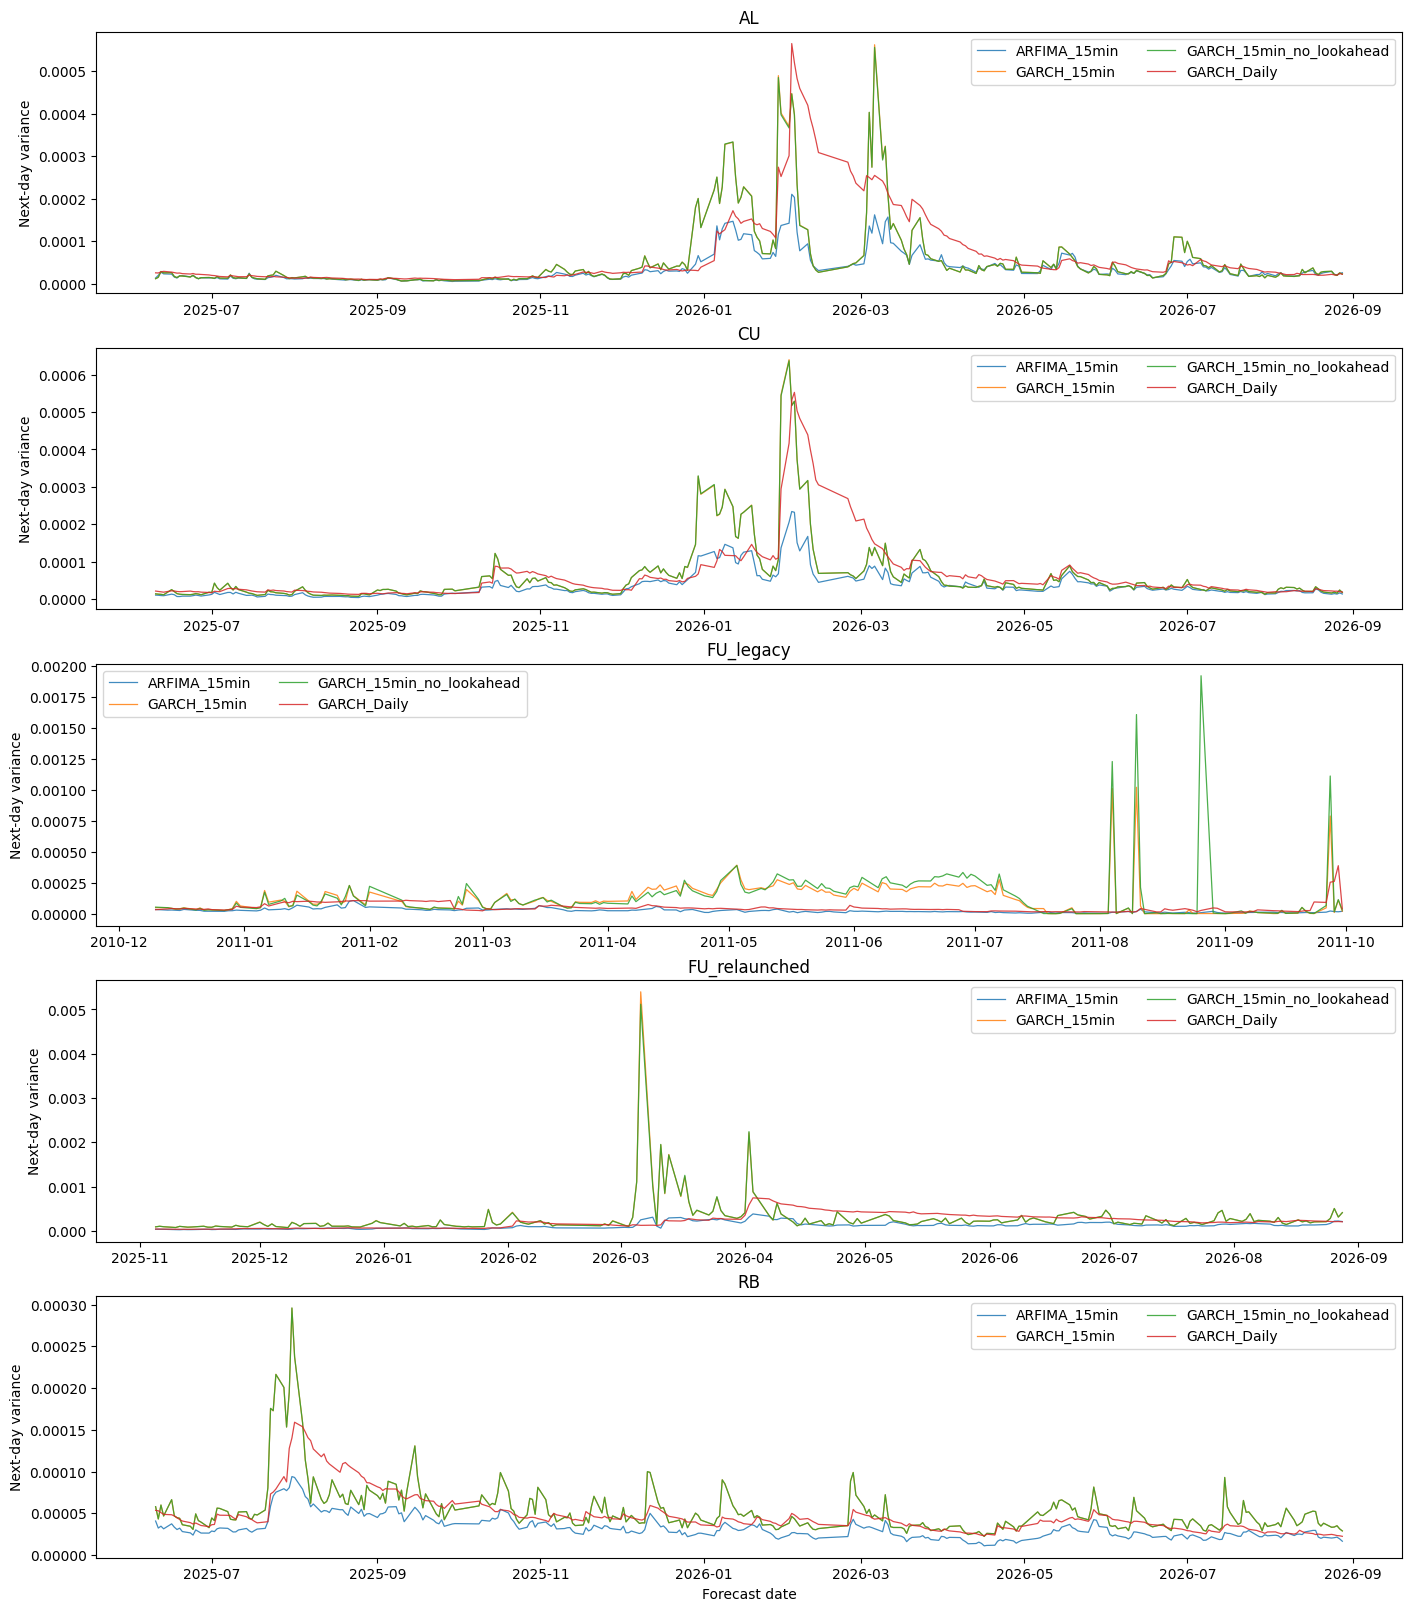

In [16]:
primary_forecast_df = forecast_panel_df.loc[
    forecast_panel_df["is_primary"]
].copy()
seasonality_sensitivity_forecast_df = forecast_panel_df.loc[
    ~forecast_panel_df["is_primary"]
].copy()

coverage_summary_df = (
    forecast_panel_df.groupby(
        ["series_id", "is_primary"],
        observed=True,
        sort=True,
    )
    .agg(
        forecast_rows=("forecast_variance", "size"),
        forecast_dates=("forecast_date", "nunique"),
        model_ids=("model_id", "nunique"),
        successful_fits=("fit_success", "sum"),
        boundary_fits=("boundary_flag", "sum"),
        fallback_grids=("fallback_grid_used", "sum"),
        roll_day_targets=("target_is_roll_day", "sum"),
        minimum_forecast=("forecast_variance", "min"),
        median_forecast=("forecast_variance", "median"),
        maximum_forecast=("forecast_variance", "max"),
    )
    .reset_index()
)

paper_intraday_df = primary_forecast_df.loc[
    (primary_forecast_df["model_class"] == "GARCH_family")
    & (primary_forecast_df["interval_label"] != "Daily"),
    [
        "series_id",
        "forecast_date",
        "model_family",
        "interval_label",
        "forecast_variance",
    ],
].rename(columns={"forecast_variance": "paper_full_sample_forecast"})
no_lookahead_intraday_df = seasonality_sensitivity_forecast_df[
    [
        "series_id",
        "forecast_date",
        "model_family",
        "interval_label",
        "forecast_variance",
    ]
].rename(columns={"forecast_variance": "no_lookahead_forecast"})
seasonality_sensitivity_comparison_df = paper_intraday_df.merge(
    no_lookahead_intraday_df,
    on=["series_id", "forecast_date", "model_family", "interval_label"],
    how="inner",
    validate="one_to_one",
)
seasonality_sensitivity_comparison_df["relative_difference"] = (
    seasonality_sensitivity_comparison_df["no_lookahead_forecast"]
    / seasonality_sensitivity_comparison_df["paper_full_sample_forecast"]
    - 1.0
)
seasonality_sensitivity_summary_df = (
    seasonality_sensitivity_comparison_df.groupby(
        ["series_id", "model_family", "interval_label"],
        observed=True,
        sort=True,
    )["relative_difference"]
    .agg(
        median_relative_difference="median",
        mean_absolute_relative_difference=lambda values: values.abs().mean(),
        maximum_absolute_relative_difference=lambda values: values.abs().max(),
    )
    .reset_index()
)

start_source_summary_df = (
    forecast_panel_df.groupby(
        ["model_class", "model_family", "selected_start_source"],
        observed=True,
        sort=True,
    )
    .size()
    .rename("selected_fits")
    .reset_index()
)

display(coverage_summary_df.round(8))
display(seasonality_sensitivity_summary_df.round(6))
display(start_source_summary_df)
display(primary_forecast_df.head(20))

figure, axes = plt.subplots(
    len(series_order),
    1,
    figsize=(14, 3.2 * len(series_order)),
    sharex=False,
    constrained_layout=True,
)
representative_model_ids = [
    "ARFIMA_15min",
    "GARCH_15min",
    "GARCH_15min_no_lookahead",
    "GARCH_Daily",
]
for axis, series_id in zip(axes, series_order, strict=True):
    plot_df = forecast_panel_df.loc[
        (forecast_panel_df["series_id"] == series_id)
        & (forecast_panel_df["model_id"].isin(representative_model_ids))
    ]
    for model_id in representative_model_ids:
        model_plot_df = plot_df.loc[plot_df["model_id"] == model_id]
        axis.plot(
            model_plot_df["forecast_date"],
            model_plot_df["forecast_variance"],
            linewidth=0.9,
            alpha=0.85,
            label=model_id,
        )
    axis.set_title(series_id)
    axis.set_ylabel("Next-day variance")
    axis.legend(ncol=2)
axes[-1].set_xlabel("Forecast date")
plt.show()

## 14. 独立公式复核、成果提交与验证门禁

In [17]:
validation_rows = []

def add_gate(gate, passed, evidence):
    validation_rows.append(
        {"gate": gate, "passed": bool(passed), "evidence": str(evidence)}
    )

expected_primary_rows = int(model_sample_df["oos_days"].sum() * 15)
expected_sensitivity_rows = int(model_sample_df["oos_days"].sum() * 9)
expected_step_rows = int(
    model_sample_df["oos_days"].sum()
    * (
        2
        * len(model_family_order)
        * interval_spec_df["expected_daily_slots"].sum()
        + len(model_family_order)
    )
)

add_gate(
    "latitude_environment",
    current_python == expected_python,
    current_python,
)
add_gate(
    "fixed_sample_and_oos_counts",
    model_sample_df.set_index("series_id")["oos_days"].to_dict()
    == {"AL": 300, "CU": 300, "FU_legacy": 200, "FU_relaunched": 200, "RB": 300},
    model_sample_df[["series_id", "initial_sample_days", "oos_days"]].to_dict("records"),
)
add_gate(
    "minute_and_slot_structure",
    minute_read_audit_df["session_alignment_failures"].eq(0).all()
    and minute_read_audit_df["selected_day_minute_rows"].sum() == 3_184_425
    and set(payload_audit_df["slots"]) == {4, 8, 15},
    f"minutes={minute_read_audit_df['selected_day_minute_rows'].sum():,}; slots=15/8/4",
)
add_gate(
    "rolling_window_dates",
    forecast_panel_df["rolling_window_days"].eq(
        forecast_panel_df["series_id"].map(
            model_sample_df.set_index("series_id")["initial_sample_days"]
        )
    ).all()
    and forecast_panel_df["estimation_end_date"].eq(
        forecast_panel_df["forecast_origin_date"]
    ).all()
    and forecast_panel_df["forecast_origin_date"].lt(
        forecast_panel_df["forecast_date"]
    ).all(),
    "每个窗口删除最老观察日、加入已实现 origin 日，目标严格在 origin 之后",
)
add_gate(
    "complete_forecast_panel",
    len(primary_forecast_df) == expected_primary_rows
    and len(seasonality_sensitivity_forecast_df) == expected_sensitivity_rows
    and len(forecast_panel_df) == 31_200,
    f"primary={len(primary_forecast_df):,}; sensitivity={len(seasonality_sensitivity_forecast_df):,}; total={len(forecast_panel_df):,}",
)
add_gate(
    "unique_forecast_key",
    not forecast_panel_df.duplicated(
        ["series_id", "forecast_date", "model_id"]
    ).any(),
    "series_id + forecast_date + model_id 唯一",
)
model_count_by_target_df = forecast_panel_df.groupby(
    ["series_id", "forecast_date", "is_primary"], observed=True
)["model_id"].nunique().unstack("is_primary")
add_gate(
    "fifteen_primary_and_nine_sensitivity_models",
    model_count_by_target_df[True].eq(15).all()
    and model_count_by_target_df[False].eq(9).all(),
    f"target grids={len(model_count_by_target_df):,}",
)
add_gate(
    "all_fits_successful",
    forecast_panel_df["fit_success"].all()
    and forecast_panel_df["optimizer_status"].eq(0).all(),
    f"successful={forecast_panel_df['fit_success'].sum():,}/{len(forecast_panel_df):,}",
)
add_gate(
    "finite_positive_forecasts",
    np.isfinite(forecast_panel_df["forecast_variance"]).all()
    and forecast_panel_df["forecast_variance"].gt(0).all(),
    f"range={forecast_panel_df['forecast_variance'].min():.3e}..{forecast_panel_df['forecast_variance'].max():.3e}",
)
add_gate(
    "model_information_boundary",
    forecast_panel_df["model_information_end"].le(
        forecast_panel_df["forecast_origin_date"]
    ).all(),
    "所有模型估计信息截止日不晚于 origin",
)
paper_seasonality_mask = (
    forecast_panel_df["seasonality_variant"].eq("paper_full_sample")
)
no_lookahead_mask = (
    forecast_panel_df["seasonality_variant"].eq("expanding_no_lookahead")
)
add_gate(
    "forward_seasonality_isolated",
    forecast_panel_df["uses_forward_seasonality"].eq(
        paper_seasonality_mask
    ).all()
    and forecast_panel_df.loc[no_lookahead_mask, "seasonality_information_end"].le(
        forecast_panel_df.loc[no_lookahead_mask, "forecast_origin_date"]
    ).all(),
    f"paper forward rows={paper_seasonality_mask.sum():,}; no-lookahead rows={no_lookahead_mask.sum():,}",
)
arfima_mask = forecast_panel_df["model_class"].eq("ARFIMA")
add_gate(
    "arfima_floor_information_boundary",
    forecast_panel_df.loc[arfima_mask, "floor_calibration_end"].le(
        forecast_panel_df.loc[arfima_mask, "forecast_origin_date"]
    ).all(),
    "ARFIMA 有效零 RV floor 永久冻结于初始样本",
)
add_gate(
    "step_panel_complete",
    len(forecast_step_df) == expected_step_rows,
    f"steps={len(forecast_step_df):,}; expected={expected_step_rows:,}",
)
step_sum_df = (
    forecast_step_df.groupby(
        ["series_id", "forecast_date", "model_id"],
        observed=True,
        sort=True,
    )["original_scale_variance_forecast"]
    .sum()
    .rename("step_sum")
    .reset_index()
)
garch_forecast_for_step_df = forecast_panel_df.loc[
    forecast_panel_df["model_class"].eq("GARCH_family"),
    ["series_id", "forecast_date", "model_id", "forecast_variance"],
]
step_sum_check_df = garch_forecast_for_step_df.merge(
    step_sum_df,
    on=["series_id", "forecast_date", "model_id"],
    validate="one_to_one",
)
step_sum_maximum_error = float(
    np.max(
        np.abs(
            step_sum_check_df["forecast_variance"]
            - step_sum_check_df["step_sum"]
        )
    )
)
add_gate(
    "step_reseasonalization_and_daily_sum",
    np.allclose(
        step_sum_check_df["forecast_variance"],
        step_sum_check_df["step_sum"],
        rtol=1e-12,
        atol=1e-16,
    ),
    f"maximum sum error={step_sum_maximum_error:.3e}",
)

representative_row = forecast_panel_df.loc[
    (forecast_panel_df["series_id"] == "AL")
    & (forecast_panel_df["model_id"] == "GARCH_15min")
].iloc[0]
representative_steps = forecast_step_df.loc[
    (forecast_step_df["series_id"] == "AL")
    & (forecast_step_df["model_id"] == "GARCH_15min")
    & (forecast_step_df["forecast_date"] == representative_row.forecast_date)
].sort_values("forecast_step")
manual_first_garch_step = (
    representative_row.omega
    + representative_row.alpha * representative_row.last_innovation**2
    + representative_row.beta * representative_row.last_conditional_variance
)
manual_second_garch_step = (
    representative_row.omega
    + (representative_row.alpha + representative_row.beta)
    * representative_steps["deseasonalized_variance_forecast"].iloc[0]
)
garch_manual_error = float(
    max(
        abs(
            manual_first_garch_step
            - representative_steps["deseasonalized_variance_forecast"].iloc[0]
        ),
        abs(
            manual_second_garch_step
            - representative_steps["deseasonalized_variance_forecast"].iloc[1]
        ),
    )
)
add_gate(
    "manual_garch_multistep_recursion",
    garch_manual_error <= 1e-10,
    f"maximum first/second-step error={garch_manual_error:.3e}",
)

daily_step_df = forecast_step_df.loc[
    forecast_step_df["model_id"].str.endswith("_Daily")
]
add_gate(
    "daily_model_unit_restoration",
    np.allclose(
        daily_step_df["seasonality_factor_squared"],
        1.0 / daily_return_model_scale**2,
        rtol=0.0,
        atol=0.0,
    ),
    "daily model variance divided by 10,000",
)

representative_arfima_row = forecast_panel_df.loc[
    (forecast_panel_df["series_id"] == "AL")
    & (forecast_panel_df["model_id"] == "ARFIMA_15min")
].iloc[0]
manual_arfima_log_forecast = (
    representative_arfima_row.mu
    + representative_arfima_row.ar1
    * representative_arfima_row.arfima_last_fractionally_differenced
    - representative_arfima_row.arfima_known_fractional_sum
)
arfima_forecast_error = float(
    abs(
        manual_arfima_log_forecast
        - representative_arfima_row.forecast_log_volatility
    )
)
arfima_restoration_error = float(
    abs(
        np.exp(2.0 * representative_arfima_row.forecast_log_volatility)
        - representative_arfima_row.forecast_variance
    )
)
add_gate(
    "manual_arfima_forecast_and_restoration",
    arfima_forecast_error <= 1e-12 and arfima_restoration_error <= 1e-16,
    f"log forecast error={arfima_forecast_error:.3e}; restoration error={arfima_restoration_error:.3e}",
)
add_gate(
    "arfima_no_bias_correction",
    not forecast_panel_df.loc[arfima_mask, "bias_correction_applied"].any(),
    "exp(2*y_hat), no undisclosed lognormal correction",
)
add_gate(
    "parameter_constraints",
    forecast_panel_df["ar1"].abs().le(arma_absolute_bound + 1e-8).all()
    and forecast_panel_df.loc[forecast_panel_df["ma1"].notna(), "ma1"].abs().le(
        arma_absolute_bound + 1e-8
    ).all()
    and forecast_panel_df.loc[forecast_panel_df["fractional_d"].notna(), "fractional_d"].abs().le(
        1.0 + 1e-8
    ).all()
    and forecast_panel_df.loc[forecast_panel_df["student_t_nu"].notna(), "student_t_nu"].gt(2).all(),
    "AR/MA bounds, FIGARCH/ARFIMA d bounds, standardized Student-t nu>2",
)
add_gate(
    "figarch_truncation",
    forecast_panel_df.loc[
        forecast_panel_df["model_family"].eq("FIGARCH"),
        "figarch_truncation",
    ].eq(figarch_truncation).all(),
    figarch_truncation,
)
add_gate(
    "warm_start_does_not_replace_reestimation",
    forecast_panel_df["candidate_count"].ge(2).all()
    and forecast_panel_df.loc[forecast_panel_df["anchor_grid"], "candidate_count"].ge(3).all(),
    f"anchors={forecast_panel_df['anchor_grid'].sum():,}; fallback grids={forecast_panel_df['fallback_grid_used'].sum():,}",
)
target_consistency_df = forecast_panel_df.groupby(
    ["series_id", "forecast_date"], observed=True
).agg(
    target_contract_codes=("target_contract_code", "nunique"),
    origin_contract_codes=("origin_contract_code", "nunique"),
    roll_flags=("target_is_roll_day", "nunique"),
)
add_gate(
    "target_contract_and_roll_consistency",
    target_consistency_df.eq(1).all().all(),
    f"target grids={len(target_consistency_df):,}",
)
add_gate(
    "fu_segments_independent",
    primary_forecast_df.loc[
        primary_forecast_df["series_id"].eq("FU_legacy"), "forecast_date"
    ].max()
    == pd.Timestamp("2011-09-30")
    and primary_forecast_df.loc[
        primary_forecast_df["series_id"].eq("FU_relaunched"), "forecast_date"
    ].min()
    > pd.Timestamp("2020-01-02"),
    "FU_legacy and FU_relaunched have separate dates, windows, parameters and warm states",
)
add_gate(
    "rb_extension_separate",
    primary_forecast_df.loc[primary_forecast_df["series_id"].eq("RB"), "model_id"].nunique() == 15
    and seasonality_sensitivity_forecast_df.loc[
        seasonality_sensitivity_forecast_df["series_id"].eq("RB"), "model_id"
    ].nunique() == 9,
    "RB primary 15 + sensitivity 9, reported outside paper commodities",
)
add_gate(
    "no_proxy_or_loss_leakage",
    not {"realized_variance", "median_variance", "parkinson_variance", "loss"}.intersection(
        forecast_panel_df.columns
    ),
    "true proxies and losses are not model inputs; item 10 will join them after forecasting",
)
add_gate(
    "project_local_stream_checkpoints",
    len(stream_summary_df) == 120
    and stream_summary_df["selected_fits"].sum() == 31_200
    and stream_summary_df["forecast_steps"].sum() == expected_step_rows
    and all(
        (
            artifact_checkpoint_dir
            / f"{stream_spec['stream_key']}.json"
        ).is_file()
        for stream_spec in stream_specs
    ),
    (
        f"run_id={run_id}; streams={len(stream_summary_df)}; "
        f"reused={stream_summary_df['reused_checkpoint'].sum()}"
    ),
)
add_gate(
    "deterministic_artifact_fingerprints",
    len(run_id) == 16
    and len(run_fingerprint) == 64
    and len(code_fingerprint) == 64
    and len(input_fingerprint) == 64
    and len(parameter_fingerprint) == 64
    and len(environment_fingerprint) == 64
    and artifact_run_dir.parent == artifact_root
    and maximum_checkpoint_path_length < 220,
    (
        f"{artifact_run_dir}; "
        f"maximum_path_length={maximum_checkpoint_path_length}"
    ),
)

validation_df = pd.DataFrame(validation_rows)
display(validation_df)
assert validation_df["passed"].all(), validation_df.loc[~validation_df["passed"]]
validated_run_manifest = commit_validated_run(
    forecast_panel_df,
    forecast_step_df,
    stream_summary_df,
    validation_df,
)
assert validated_run_manifest["status"] == "complete"
assert validated_run_manifest["run_id"] == run_id
display(
    pd.DataFrame(
        {
            "run_id": [run_id],
            "artifact_status": [validated_run_manifest["status"]],
            "stream_checkpoints": [
                validated_run_manifest["stream_checkpoint_count"]
            ],
            "consolidated_files": [
                len(validated_run_manifest["consolidated_files"])
            ],
            "artifact_run_dir": [str(artifact_run_dir)],
        }
    )
)
print(
    f"全部 {len(validation_df)} 项验证门禁通过；"
    "完整项目成果已提交并复读。"
)

,gate,passed,evidence
0,latitude_environment,True,E:\anaconda3\envs\latitude\python.exe
1,fixed_sample_and_oos_counts,True,"[{'series_id': 'AL', 'initial_sample_days': 3745, 'oos_days': 300}, {'series_id': 'CU', 'initial_sample_days': 3745, 'oos_days': 300}, {'series_id': 'FU_legacy', 'initial_sample_days': 204, 'oos_days': 200}, {'series_id': 'FU_relaunched', 'initial_sample_days': 1414, 'oos_days': 200}, {'series_id': 'RB', 'initial_sample_days': 3745, 'oos_days': 300}]"
2,minute_and_slot_structure,True,"minutes=3,184,425; slots=15/8/4"
3,rolling_window_dates,True,每个窗口删除最老观察日、加入已实现 origin 日，目标严格在 origin 之后
4,complete_forecast_panel,True,"primary=19,500; sensitivity=11,700; total=31,200"
5,unique_forecast_key,True,series_id + forecast_date + model_id 唯一
6,fifteen_primary_and_nine_sensitivity_models,True,"target grids=1,300"
7,all_fits_successful,True,"successful=31,200/31,200"
8,finite_positive_forecasts,True,range=3.242e-12..1.209e+09
9,model_information_boundary,True,所有模型估计信息截止日不晚于 origin


,run_id,artifact_status,stream_checkpoints,consolidated_files,artifact_run_dir
0,eaf4757d3488c2b7,complete,120,4,E:\Latitude_Analytics_v2\01_project_collection\china_commodity_futures_intraday_volatility_forecasting_reproduction\data\item09\eaf4757d3488c2b7


全部 27 项验证门禁通过；完整项目成果已提交并复读。


## 15. 结果解释与限制

运行完成后应先读覆盖表与门禁，再看预测水平。31,200 行包含 19,500 行论文主口径和 11,700 行无前视季节因子敏感性；后者是完整重新估计，不是对主预测的事后缩放。

解释边界：

1. 这一项只生成预测，不使用 RV、MedRV 或 Parkinson 判断优胜；任何模型排名必须等第 10 项共同损失计算。
2. 论文全文季节因子明确含前视，`uses_forward_seasonality=True` 将其隔离；无前视扩展因子才代表 forecast-origin 信息集。
3. 多步预测汇总的是条件创新方差，不加 ARMA 均值平方或跨槽协方差；这是最贴近论文文字但作者未披露的项目解释。
4. FIGARCH analytic forecast、1000 阶截断、固定窗口长度、每日完整重估、起点策略和失败硬停止均是论文未披露的透明项目选择。
5. 日频模型仍使用 Session 内日收益而非 close-to-close；FU 两段和 RB 始终独立。
6. stream checkpoint 与完整面板是本项目唯一获授权的持久化研究成果，不属于 raw/silver/gold。第 10–12 项只能读取 README 固定的已验收 `run_id`；缺失或损坏时硬失败，不回退到 `LATEST`，也不静默重算。